# LONG-SHORT TERM MEMORY: BUILD-UP & TUNING

### FILE PURPOSES & MODEL BUILD-UP PROCEDURE

Implementing a LSTM could be tricky. That's why a different file has been created. This document's purpose is twofold: *a)* assesing whether a LSTM is a suitable model for the dataset and *b)* tuning the top-performing data set. 
The steps taken are the following:

- **Baseline model**: Build a vanilla-LSTM and the training data and check whether or not it overfits. If it does, then an LSTM could gather meaningful patters within data.
- **Regularized model**: Build a lightly-tuned LSTM with regularization and evaluate it through cross-validation within the traning set.
- **Stacked model**: Construct a multi-layer (stacked) LSTM and evaluate it through cross-validation within the training set.
- **Model Comparison**: Compare outcomes from the stacked and the regularized model using metrics like MSE, R-squared and MAE. Actual vs predicted plots are used too.
- **Hyperparameters Tuning**: Tune the top-performing model's hyperparameters. Tuning is done both through random search and bayesian optimization.
- **Adding White noise**: Add white noise to check if model's performances improve. If that's the case, lightly re-tune a LSTM model having a Gaussian Noise layer.
- **Final Evaluation**: Evaluate the top-performing model on the held-out validation set. 

**Note.** All models are run for *n*-iterations across *n*-folds, and performance metrics are averaged for transparency. However, only the single best model is saved for deployment.

#### EVALUATION METRICS

Evaluation Metrics are the same as the ones already taken into consideration. These are:
  
- RMSE
- MAE
- R-squared

With RMSE as the main metrics for comparison.

## IMPORTING PACKAGES

In [6]:
#access AWS through credentials
import boto3
import os
from io import StringIO, BytesIO
import random

#data manipulation
import numpy as np
import pandas as pd

#plotting
import seaborn as sns
import matplotlib.pyplot as plt

#save models
import pickle
import joblib
import json #saving parameters
#for lstm
from joblib import dump #save
from joblib import load #load

#build linear models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
#compute evaluation metrics
from sklearn.metrics import make_scorer, root_mean_squared_error, mean_absolute_error, r2_score

#random forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import plot_tree

#xgboosting
from xgboost import XGBRegressor, plot_importance

#lightGBM
from lightgbm import LGBMRegressor

#SVR
from sklearn.svm import SVR

#metrics
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
#cross-validation w/ time series
from sklearn.model_selection import TimeSeriesSplit

#LSTM
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GaussianNoise, LSTM, Dense, Dropout, Input
from keras.optimizers import Adam, RMSprop
from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasRegressor
import tensorflow as tf
from typing import Union, List, Tuple
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2
from tensorflow.keras import Sequential, Input

#BAYESIAN OPTIMIZATION
from skopt import gp_minimize
from skopt.space import Integer, Real, Categorical
from skopt.utils import use_named_args
from skopt.plots import plot_convergence

2025-10-22 21:18:11.268904: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-22 21:18:11.331146: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-22 21:18:12.940682: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [ ]:
#path to models
path = "../models/"

## DEFINING USEFUL FUNCTION

- Transforms time series features and labels into sequences suitable for training LSTM models.

In [8]:
def create_sequences_from_X_y(X_df, y_array, window_size=20):
    """
    Transforms time series features and labels into sequences suitable for training LSTM models.

    Parameters:
    -----------
    X_df : pd.DataFrame
        A DataFrame containing the input features, including a 'date' column which will be dropped.
    y_array : Union[pd.Series, np.ndarray]
        The target variable corresponding to X_df, either as a Series or NumPy array.
    window_size : int, default=20
        The number of past time steps to include in each input sequence.

    Returns:
    --------
    X_seq : np.ndarray
        3D array of shape (samples, window_size, features) for LSTM input.
    y_seq : np.ndarray
        1D array of target values aligned with each input sequence.
    """

    # Ensure the DataFrame index is sequential (0 to N-1)
    X_df = X_df.reset_index(drop=True)

    # Drop the 'date' column and convert remaining features to NumPy array
    X_values = X_df.drop(columns=['date']).values

    # Convert y_array to NumPy array and reset index if it's a Series
    if isinstance(y_array, pd.Series):
        y_array = y_array.reset_index(drop=True).values
    else:
        y_array = np.array(y_array)

    # Initialize lists to collect sequences
    X_seq, y_seq = [], []

    # Loop over the data to create sequences of length `window_size`
    for i in range(window_size, len(X_df)):
        # Get the window of features ending at position i (exclusive)
        X_seq.append(X_values[i-window_size:i])

        # Get the target value aligned with the current sequence
        y_seq.append(y_array[i])  # safe since y_array is now a NumPy array

    # Convert the lists to NumPy arrays and return
    return np.array(X_seq), np.array(y_seq)


## DATA PREPARATION

Let's load the datasets from the AWS bucket. This process is the same as in the main analysis, hence no further comments are added.

In [9]:
# Use the AWS Access and Secret keys if not available
s3 = boto3.client('s3')

In [ ]:
# Set AWS credentials as environment variables
os.environ['AWS_ACCESS_KEY_ID'] = " " #add access key
os.environ['AWS_SECRET_ACCESS_KEY'] = " " #add secret access key
os.environ['AWS_DEFAULT_REGION'] = " "  #select region

In [ ]:
# Initialize S3 client
s3 = boto3.client('s3')

# Define the S3 bucket name
bucket_name = ' ' 

# List objects in the bucket
response = s3.list_objects_v2(Bucket=bucket_name)

# Check if the bucket has objects
if 'Contents' in response:
    for item in response['Contents']:
        print(item['Key'])
else:
    print("No files found in the bucket")

crypto_volatility21_fe.csv
crypto_volatility21_fe.parquet
crypto_volatility30_fe.csv
crypto_volatility30_fe.parquet
crypto_volatility_clean.csv
crypto_volatility_clean.parquet
crypto_volatility_fe5.csv
crypto_volatility_fe5.parquet
crypto_volatility_raw.csv
crypto_volatility_raw.parquet
scaled_data/X_tr_scal.csv
scaled_data/X_tr_scal21.csv
scaled_data/X_tr_scal30.csv
scaled_data/X_tr_scal_ewm.csv
scaled_data/X_tr_scal_ewm_noStd.csv
scaled_data/X_tt_scal.csv
scaled_data/X_tt_scal21.csv
scaled_data/X_tt_scal30.csv
scaled_data/X_tt_scal_ewm.csv
scaled_data/X_tt_scal_ewm_noStd.csv
scaled_data/X_val_scal.csv
scaled_data/X_val_scal21.csv
scaled_data/X_val_scal30.csv
scaled_data/X_val_scal_ewm.csv
scaled_data/X_val_scal_ewm_noStd.csv
scaled_data/y_tr_scal.csv
scaled_data/y_tr_scal21.csv
scaled_data/y_tr_scal30.csv
scaled_data/y_tr_scal_ewm.csv
scaled_data/y_tt_scal.csv
scaled_data/y_tt_scal21.csv
scaled_data/y_tt_scal30.csv
scaled_data/y_tt_scal_ewm.csv
scaled_data/y_val_scal.csv
scaled_data/

In [12]:
# Initialize boto3 client
s3 = boto3.client('s3')

In [13]:
# dictionary to store all the dataframes (both scaled and not)
dataframes = {}

In [14]:
# S3 bucket and file keys for scaled data
file_keys_scaled = [
    'scaled_data/X_tr_scal_ewm.csv', 
    'scaled_data/X_tt_scal_ewm.csv',
    'scaled_data/X_val_scal_ewm.csv',
    'scaled_data/y_tr_scal_ewm.csv',
    'scaled_data/y_tt_scal_ewm.csv',
    'scaled_data/y_val_scal_ewm.csv'
]

# Loop and assign each df to a variable and to the dictionary
for key in file_keys_scaled:
    response = s3.get_object(Bucket=bucket_name, Key=key)
    csv_content = response['Body'].read().decode('utf-8')

    #name the df
    df_name = key.removeprefix('scaled_data/').removesuffix('_ewm.csv')
    #transform csv into a pd df
    df = pd.read_csv(StringIO(csv_content), index_col=0)

    # Assign to dictionary
    dataframes[df_name] = df

    # Assign to a variable in global scope
    globals()[df_name] = df

In [15]:
# S3 bucket and file keys for unscaled data
file_keys = [
    'unscaled_data/X_tr_ewm.csv', 
    'unscaled_data/X_tt_ewm.csv',
    'unscaled_data/X_val_ewm.csv',
    'unscaled_data/y_tr_ewm.csv',
    'unscaled_data/y_tt_ewm.csv',
    'unscaled_data/y_val_ewm.csv',
]

# Loop and assign each df to a variable and to the dictionary
for key in file_keys:
    response = s3.get_object(Bucket=bucket_name, Key=key)
    csv_content = response['Body'].read().decode('utf-8')

    df_name = key.removeprefix('unscaled_data/').removesuffix('_ewm.csv') #name the df
    df = pd.read_csv(StringIO(csv_content), index_col=0)#transform csv into a pd df

    # Assign to dictionary
    dataframes[df_name] = df

    # Assign to a variable in global scope
    globals()[df_name] = df

In [16]:
#check df has been properly loaded
print(X_tr_scal)

            date     close    volume     trend  fg_index  cluster  log_return  \
0     2018-02-07 -0.712976  0.168652  1.116642 -0.367605        0   -0.199027   
1     2018-02-08 -0.702790 -1.540343  0.657685 -0.632067        0    0.587014   
2     2018-02-09 -0.653246 -0.993489  0.313466 -0.014990        0    2.749266   
3     2018-02-10 -0.661501 -0.160041 -0.088122  0.425780        0   -0.463748   
4     2018-02-11 -0.687382 -0.285679 -0.260231 -0.587990        4   -1.458020   
...          ...       ...       ...       ...       ...      ...         ...   
1577  2022-06-03  0.503800 -0.024896 -0.317600 -1.513607        5   -0.656318   
1578  2022-06-04  0.512820 -0.845393 -0.547079 -1.337299        5    0.116901   
1579  2022-06-05  0.515857 -0.916859 -0.604449 -1.513607        5    0.024292   
1580  2022-06-06  0.595901  0.401062 -0.317600 -1.381376        5    1.179715   
1581  2022-06-07  0.582260  1.607676 -0.145491 -1.293222        5   -0.223354   

      hl_spread  momentum_3

In [17]:
# load the scaler from S3
#define the scaler
scaler_key = "scaler_y.pkl"
#load the scaler
scaler_response = s3.get_object(Bucket=bucket_name, Key=scaler_key)
scaler_y = joblib.load(BytesIO(scaler_response['Body'].read())) #BytesIO treat a binary output as a file

### N-RUNs AND CROSS-VALIDATION SPLIT

Model performance is averaged across 5 independent runs. The number of runs was set to 5 to balance computational efficiency with reliable results. 
Cross-validation was performed using 3 splits to ensure that each fold retained a sufficient amount of data. Since the data is time-series in nature, the splits were generated chronologically. Compared to other models, fewer splits were used here to limit computational overhead.

In [18]:
#define the number of runs
n_runs = 5
#define the number of split for cross validation (in each run there are n_split folds)
n_splits = 3

### LSTM SEQUENCE PREPARATION

To feed data into a LSTM model, it must be in a LSTM-compatible format. In this case, both training and validation data is transformed into overlapping sequence of length = 20. This means that for each prediction, the model observes the previous 20 time steps to forecast the 21st

In [19]:
#Generate sequences and targets for LSTM with window size 20 for training
X_lstm, y_lstm = create_sequences_from_X_y(X_tr_scal, y_tr_scal, window_size=20)
#windows_size tells how much the model looks back to predict the next point (ex if = 20, model looks at the last 20 observations to predict the next one)
#it is the length of each input sequence and corresponding target.

In [20]:
# Generate sequences and targets for LSTM with window size 20 for validation
X_lstm_val, y_lstm_val = create_sequences_from_X_y(X_val_scal, y_val_scal, window_size=20)
#windows size stays the same

## LSTM MODELS

### VANILLA LSTM

The first step is to implement a vanilla LSTM to undertsand if this kind of model grasps some dataset's patterns. 
In details, the baseline parameters are:  

- units = 64
- learning rate = 0.001
- optimizer = Adam
- loss function = mse
- epochs = 100
- batch size = 32

This setup provides a balanced LSTM architecture: lightweight enough to train efficiently, yet sufficiently robust to model the data effectively.

In [22]:
# build the vanilla LSTM model and fit on the training set to see if overfits
def build_base_model(input_shape, 
                     units=64, #number of neurons
                     learning_rate=0.001): #how fast the model updates weights during tuning
    model = Sequential([
        Input (shape=input_shape), #data input
        LSTM(units), #LSTM with given units
        Dense (1) #output layer
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate) #type of optimizer
    model.compile(optimizer=optimizer, loss='mse') #lower the mse, the better
    return model #oupt the model

In [23]:
#define the base_model
base_model = build_base_model(input_shape=(X_lstm.shape[1], X_lstm.shape[2]))

#compile the model and save its history
base_history = base_model.fit(
    X_lstm, y_lstm, #data input
    epochs = 100, #epochs' number
    batch_size = 32, #number of samples that will be propagated through the network
    verbose = 1 #written output
)

Epoch 1/100


2025-09-12 12:56:53.019581: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.6724
Epoch 2/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.5146
Epoch 3/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.4017
Epoch 4/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3282
Epoch 5/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3311
Epoch 6/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3484
Epoch 7/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.2981
Epoch 8/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4279
Epoch 9/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.3383
Epoch 10/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3605
Epoch 11/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.3271
Epoch 12/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3624
Epoch 13/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2311
Epoch 14/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.3043
Epoch 15/100
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3090
Epoch 16/100

As a first sanity check, training loss over epochs is considered.

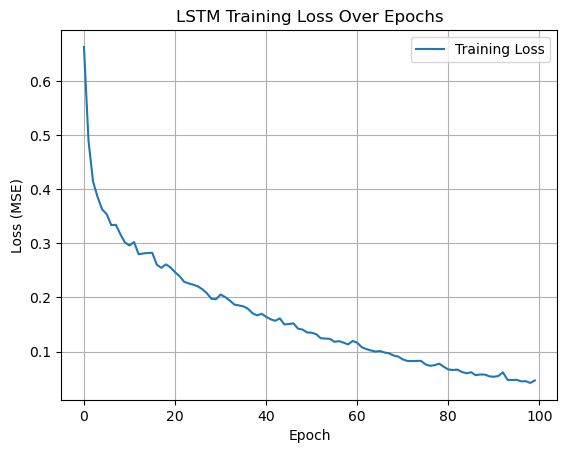

In [24]:
#plot the loss function vs epochs
plt.plot(base_history.history['loss'], label='Training Loss')
plt.title('LSTM Training Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

A consistently decreasing curve (with minor fluctuations) shows that the model is indeed learning patterns from the data.

To be even more confident, let's compare the predicted vs the actual values on the training set. The closer their alignment (along with the evaluation metrics), the more the model is overfitting.

In [25]:
#make predictions on the training set
base_preds = base_model.predict(X_lstm)
#inverse scale the prediction
base_preds = scaler_y.inverse_transform(np.array(base_preds).reshape(-1, 1)).ravel()
#inverse scale the actual values
y_true = scaler_y.inverse_transform(y_lstm.reshape(-1, 1)).ravel()

49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [26]:
##Compute evaluation metrics
#rmse
base_rmse = np.sqrt(mean_squared_error(y_true, base_preds))
#mae
base_mae = mean_absolute_error(y_true, base_preds)
#r2
base_r2 = r2_score(y_true, base_preds)
#print all the metrics
print(f"Validation RMSE: {base_rmse:.4f}")
print(f"Validation MAE : {base_mae:.4f}")
print(f"Validation R²  : {base_r2:.4f}")

Validation RMSE: 0.0041
Validation MAE : 0.0027
Validation R²  : 0.9629


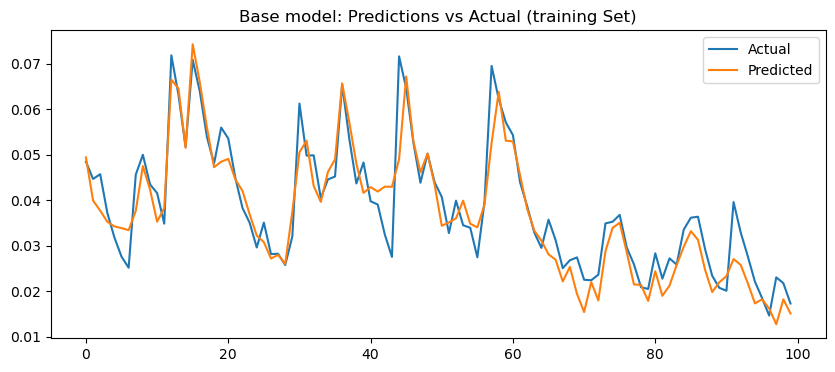

In [27]:
#plot actual vs predicted
plt.figure(figsize=(10,4))
plt.plot(y_true[:100], label='Actual')
plt.plot(base_preds[:100], label='Predicted')
plt.title('Base model: Predictions vs Actual (training Set)')
plt.legend()
plt.show()

As the evaluation metrics and the plot show, the vanilla LSTM is overfitting the training data. Altogether, these prove the model's capacity to capture the dataset's patterns.

Therefore, by tweaking the model's hyperparameters it is possible to generalize its performances beyond the simple training set.

### REGULARIZED LSTM

Regularization aims to prevent overfitting by limiting the model's flexibility and leading to better generalization. As such, the architecture and hyperpameters remain the same as in vanilla version. Yet, the following constraints are added:

- dropout rate = 0.3
- l2 lambda = 0.001
- recurrent dropout = 0.2
- early stopping with a patience = 10

Altogether, these ensures the model *a)* does not rely on all available neurons at once *b)* penalizes too complex weights and *c)* stops early if the loss function is not improving.

In [28]:
#define the regularized model
def build_regularized_model(input_shape,
                            units=64,
                            dropout_rate=0.3, #inputs to drop between series 
                            l2_lambda=0.001, #value of the penalty term multiplier
                            learning_rate=0.001):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units, 
             kernel_regularizer=l2(l2_lambda), # penalty term to the layer's weights to reduce overfitting
             recurrent_dropout=0.2), #drops connections between time steps
        Dropout(dropout_rate),
        Dense(1)
    ])
    #define the optimized
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    #compile the model (loss is mse)
    model.compile(optimizer=optimizer, loss='mse')
    #return the model
    return model

# Instantiate early stopping on validation loss
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
#if the validation loss does not improve for 10 consecutives epochs, 
#stop training early and restore the best weights 


In [29]:
#ITERATE THE MODEL TRHOUGH FOLDS, SAVE THE BEST MODEL AND DISPLAY THE AVG PERFORMANCES

# Store metrics across runs
rmse_list_reg = []
mae_list_reg = []
r2_list_reg = []

#store the best rmse and the best_model info
best_rmse = np.inf
best_model_info = {}

#define the path to save the top-performing model
reg_save_path = "models/LSTM/LSTM_reg/"
os.makedirs(reg_save_path, exist_ok=True)

#set up a loop to perform n-runs, 
for run in range(n_runs):
    print(f"\n=== Run {run + 1}/{n_runs} ===") #show the run 
    
    # Fold metrics
    fold_rmse = []
    fold_mae = []
    fold_r2 = []

    #define the tscv split
    tscv = TimeSeriesSplit(n_splits=n_splits)

    #re-iterate model building for each cross-validation split (defined by n_splits)
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_lstm)):
        #print fold number
        print(f"\n--- Fold {fold + 1}/{n_splits} ---")

        #split into train-val both X and y
        X_train, X_val = X_lstm[train_idx], X_lstm[val_idx]
        y_train, y_val = y_lstm[train_idx], y_lstm[val_idx]

        # Build a fresh model
        model_reg = build_regularized_model(input_shape=(X_lstm.shape[1], X_lstm.shape[2]))

        #compile the history for the model
        history_reg = model_reg.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=32,
            callbacks=[early_stop],
            verbose=1
        )

        # Prediction (inverse scaled)
        y_pred = model_reg.predict(X_val)
        y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
        y_true = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()

        # Metrics
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        #add the metrics to the fold's list
        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)

        #show the fold's metrics
        print(f"Fold RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")

        # Save model if best so far (commented out as it has already been saved)  
        if rmse < best_rmse:
            best_rmse = rmse
            #model_stack.save(reg_save_path + "regSplit_LSTM.keras")
            #np.save(reg_save_path + "regSplit_valPred.npy", y_pred)
            #np.save(reg_save_path + "regSplit_valTrue.npy", y_true)
            #np.save(reg_save_path + "regSplit_history.npy", history_reg.history)
            #print("Best model updated and saved.")

    # Average fold performance
    avg_rmse = np.mean(fold_rmse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

    #add the avg metrics to the related list
    rmse_list_reg.append(avg_rmse)
    mae_list_reg.append(avg_mae)
    r2_list_reg.append(avg_r2)

    #show the avg metrics for the run
    print(f"\n[Run {run + 1}] Avg RMSE: {avg_rmse:.4f}, MAE: {avg_mae:.4f}, R²: {avg_r2:.4f}")

# Final summary
print("\n=== Aggregated Performance over", n_runs, "runs ===")
print(f"RMSE: Mean = {np.mean(rmse_list_reg):.4f}, Std = {np.std(rmse_list_reg):.4f}")
print(f"MAE : Mean = {np.mean(mae_list_reg):.4f}, Std = {np.std(mae_list_reg):.4f}")
print(f"R²  : Mean = {np.mean(r2_list_reg):.4f}, Std = {np.std(r2_list_reg):.4f}")
print(f"\n🎯 Best model had RMSE = {best_rmse:.4f} and was saved to: {reg_save_path}")

#loss and val_loss in each epoch is on scaled, therefore is much larger 
#than final RMSE that is on onverse scaled data
#MSE is chosen as the main metrics as it is the square root of RMSE, the main metric for comparison



=== Run 1/5 ===

--- Fold 1/3 ---
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 0.7235 - val_loss: 1.6460
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3986 - val_loss: 1.4704
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3315 - val_loss: 1.3678
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 0.2854 - val_loss: 1.3156
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.2877 - val_loss: 1.2542
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.3206 - val_loss: 1.2145
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2516 - val_loss: 1.1861
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.2900 - val_loss: 1.1678
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2188 - val_loss: 1.1422
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.2252 - val_loss: 1.1110
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.2413 - val_loss: 1.1016
Epoch 12/100
13/1

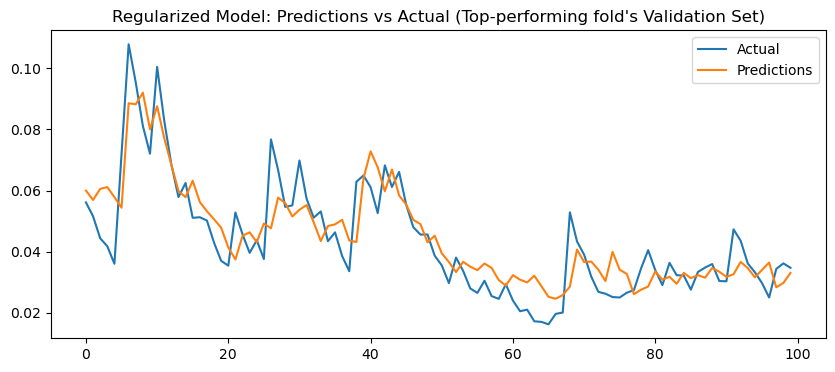

In [30]:
#load the predictions from the regularized model
y_pred_reg = np.load(reg_save_path + "regSplit_valPred.npy")
#load the actual val set for that split
y_true_reg = np.load(reg_save_path + "regSplit_valTrue.npy")
##Note. this is done as training and validation sets are split due to tscv (in each fold there is a train and a val,
#this keep the best train-val split that got the best evaluation metrics)

#plot actual vs predicted val sets
plt.figure(figsize=(10,4))
plt.plot(y_true_reg[:100], label='Actual')
plt.plot(y_pred_reg[:100], label='Predictions')
plt.title("Regularized Model: Predictions vs Actual (Top-performing fold's Validation Set)")
plt.legend()
#show it
plt.show()
##Not done on the entire train-split as it is just as a screening-model-assessment

Once regularized, the LSTM generalizes just fine on unseen data; as it successfully catches the major trends.
However, the plots and the evaluation metrics hint the model has some unexplored potential. This was expected, as the regularized has not been fine-tuned yet. 

The next step is to add one more layer to this very same LSTM and assess its outcomes. If these improve, it means complexity adds explicative power to the model.

### STACKED LSTM

In [32]:
#define the function to build the stacked model (layer > 1)
def build_stacked_model(input_shape, 
                        units_1=64, #units in the 1st layer
                        units_2=32, #units in the 2nd layer
                        dropout_rate=0.3, 
                        l2_lambda=0.001, 
                        learning_rate=0.001):
    #define the model
    model = Sequential([
        Input(shape=input_shape),
        
        # First LSTM layer
        LSTM(units_1, #32
             return_sequences=True, #done to pass sequence to next layer
             kernel_regularizer=l2(l2_lambda), 
             recurrent_dropout=0.2),
        Dropout(dropout_rate),
        
        # Second LSTM layer (default return_sequences=False so it passed to the output)
        LSTM(units_2, #16
             kernel_regularizer=l2(l2_lambda), 
             recurrent_dropout=0.2),
        Dropout(dropout_rate),
        
        # Output layer
        Dense(1)
    ])
    #define the optimizer
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    #compile the model
    model.compile(optimizer=optimizer, loss='mse')
    #return the model
    return model

In [33]:
#ITERATE THE MODEL THROUGH FOLDS, SAVE THE BEST MODEL AND DISPLAY THE AVG PERFORMANCES
#Note. n_runs and n_splits are not defined again as are the same as for the regularized model

# lists to store metrics across runs
rmse_list_stack = []
mae_list_stack = []
r2_list_stack = []

#store the best rmse and the best_model info
best_rmse = np.inf
best_model_info = {}

#define the saving path for the top-performing model
stack_save_path = "models/LSTM/LSTM_stack/"
os.makedirs(stack_save_path, exist_ok=True)

#set up a loop to perform n-runs
for run in range(n_runs):
    print(f"\n=== Run {run + 1}/{n_runs} ===") #show the run's number
    
    # Fold metrics
    fold_rmse = []
    fold_mae = []
    fold_r2 = []

    #define the time series cv split
    tscv = TimeSeriesSplit(n_splits=n_splits)

    #re-iterate model building for each cross-validation split (defined by n_splits)
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_lstm)):
        #print fold number
        print(f"\n--- Fold {fold + 1}/{n_splits} ---")

        #split into train-val both X and y
        X_train, X_val = X_lstm[train_idx], X_lstm[val_idx]
        y_train, y_val = y_lstm[train_idx], y_lstm[val_idx]

        # Build a fresh model
        model_stack = build_stacked_model(input_shape=(X_lstm.shape[1], X_lstm.shape[2]))

        #compile the history for the model
        history_stack = model_stack.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=32,
            callbacks=[early_stop],
            verbose=1
        )

        # Prediction (inverse scaled)
        y_pred = model_stack.predict(X_val)
        y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
        y_true = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()

        # Metrics
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        #add the metrics to the fold's list
        fold_rmse.append(rmse)
        fold_mae.append(mae)
        fold_r2.append(r2)

        #show the fold's metrics
        print(f"Fold RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")
        
        # Save model if best so far (commented out as it has already been saved)    
        if rmse < best_rmse:
            best_rmse = rmse
            #model_stack.save(stack_save_path + "stacked_LSTM.keras")
            #np.save(stack_save_path + "stacked_valPred.npy", y_pred)
            #np.save(stack_save_path + "stacked_valTrue.npy", y_true)  # ADD THIS LINE
            #np.save(stack_save_path + "stacked_history.npy", history_stack.history)
            print("✔️  Best model updated and saved.")

    # Average fold performance
    avg_rmse = np.mean(fold_rmse)
    avg_mae = np.mean(fold_mae)
    avg_r2 = np.mean(fold_r2)

    #add the avg metrics to the related list
    rmse_list_stack.append(avg_rmse)
    mae_list_stack.append(avg_mae)
    r2_list_stack.append(avg_r2)

    #show the avg metrics for the run
    print(f"\n[Run {run + 1}] Avg RMSE: {avg_rmse:.4f}, MAE: {avg_mae:.4f}, R²: {avg_r2:.4f}")

# Final summary
print("\n=== Aggregated Performance over", n_runs, "runs ===")
print(f"RMSE: Mean = {np.mean(rmse_list_stack):.4f}, Std = {np.std(rmse_list_stack):.4f}")
print(f"MAE : Mean = {np.mean(mae_list_stack):.4f}, Std = {np.std(mae_list_stack):.4f}")
print(f"R²  : Mean = {np.mean(r2_list_stack):.4f}, Std = {np.std(r2_list_stack):.4f}")
print(f"\n🎯 Best model had RMSE = {best_rmse:.4f} and was saved to: {stack_save_path}")


=== Run 1/5 ===

--- Fold 1/3 ---
Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 81ms/step - loss: 0.6670 - val_loss: 1.9278
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.5015 - val_loss: 1.9140
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.5733 - val_loss: 1.8613
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.4135 - val_loss: 1.7159
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.4536 - val_loss: 1.7589
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.4270 - val_loss: 1.6180
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.4039 - val_loss: 1.6242
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.3994 - val_loss: 1.5672
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.3630 - val_loss: 1.5566
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.3176 - val_loss: 1.4965
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3437 - val_loss: 1.4634
Epoch 12/100
13/1

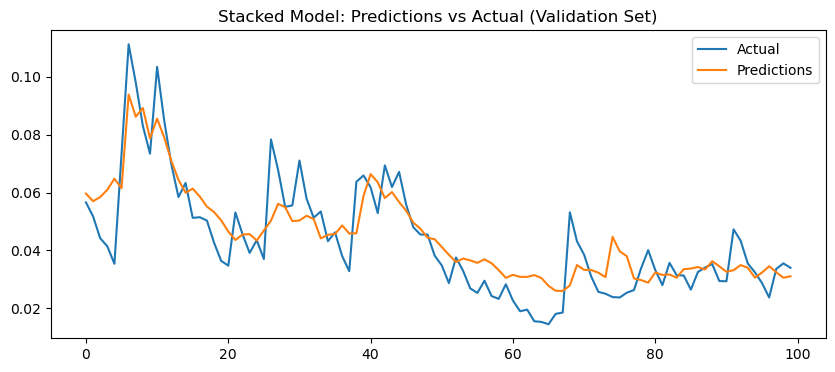

In [34]:
#load the best y-estimation from the stacked model
y_pred_stack = np.load(stack_save_path + "stacked_valPred.npy")
#load the actuals val set for that split
y_true_stack = np.load(stack_save_path + "stacked_valTrue.npy")
##Note. this is done as training and validation sets are split due to tscv (in each fold there is a train and a val,
#this keep the best train-val split that got the best evaluation metrics)

#plot actual vs predicted val sets
plt.figure(figsize=(10,4))
plt.plot(y_true_stack[:100], label='Actual')
plt.plot(y_pred_stack[:100], label='Predictions')
plt.title('Stacked Model: Predictions vs Actual (Validation Set)')
plt.legend()
#show it
plt.show()
##Not done on the entire train-split as it is just as a screening-model-assessment

Complexity does not seem neither to add explanatory power nor helping in grasping minor trends. Overall, adding more layers does not appear to be that beneficial.

To get the clear picture, let's compare the two models' performances.

#### MODELS COMPARISON

Regularized model performances (averages):
RMSE: 0.0156
MAE : 0.0103
R²  : 0.4101
------------------------------------------
Stacked model performances (averages):
RMSE: 0.0171
MAE: 0.0113
R²: 0.2944
Predicted vs Actual plot: regularized vs stacked model


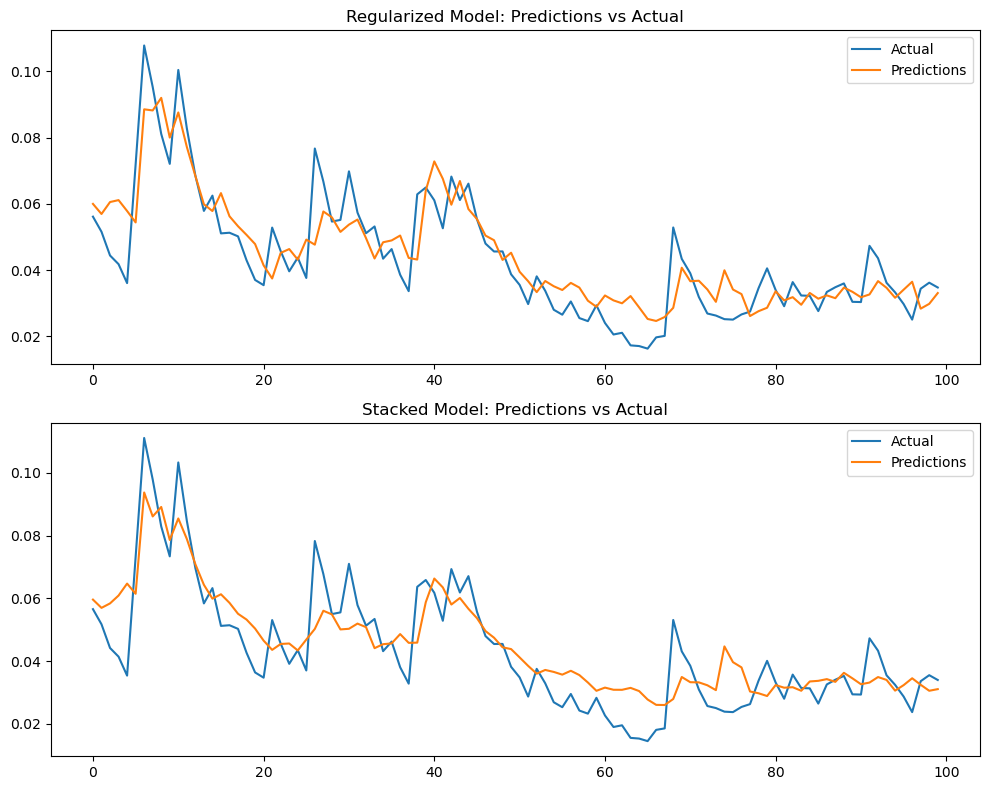

In [35]:
#Show both the regularized and stacked LSTM and compare them
#regularized model
print("Regularized model performances (averages):")
print(f"RMSE: {np.mean(rmse_list_reg):.4f}")
print(f"MAE : {np.mean(mae_list_reg):.4f}")
print(f"R²  : {np.mean(r2_list_reg):.4f}")
print("------------------------------------------")
#stacked model
print("Stacked model performances (averages):")
print(f"RMSE: {np.mean(rmse_list_stack):.4f}")
print(f"MAE: {np.mean(mae_list_stack):.4f}")
print(f"R²: {np.mean(r2_list_stack):.4f}")

# show the plots together
#regularized plot
#define fig and axis
fig1, ax1 = plt.subplots()
#build the fig as above
ax1.plot(y_true_reg[:100], label='Actual')
ax1.plot(y_pred_reg[:100], label='Predictions')
ax1.set_title("Regularized Model: Predictions vs Actual")
ax1.legend()
#store the axis
regularized_plot = ax1
#avoid showing it
plt.close(fig1)

#stacked plot
#define fig and axis
fig2, ax2 = plt.subplots()
#build the fig as above
ax2.plot(y_true_stack[:100], label='Actual')
ax2.plot(y_pred_stack[:100], label='Predictions')
ax2.set_title("Stacked Model: Predictions vs Actual")
ax2.legend()
#store the axis
stacked_plot = ax2
#avoid displaying it
plt.close(fig2)

#give a title
print("Predicted vs Actual plot: regularized vs stacked model")
#define the layout
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 8))
# Copy content from stored plots
#regularized
for line in regularized_plot.lines:
    ax_top.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
ax_top.set_title("Regularized Model: Predictions vs Actual")
ax_top.legend()
#stacked
for line in stacked_plot.lines:
    ax_bottom.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
ax_bottom.set_title("Stacked Model: Predictions vs Actual")
ax_bottom.legend()
#show them
plt.tight_layout()
plt.show()

Comparing the evaluation metrics side-by-side confirms the regularized model's better performances. Specifically, the regularized LSTM yields not only a lower RMSE and MAE, but also a bigger R-squared compared to the stacked model.
The plots visually validate these claims.

As a result, the regularized LSTM will be fine-tuned.

## HYPERPARAMETERS TUNING: REGULARIZED MODEL

Fine-tuning Hyperparamter is crucial to maximize model's outcome. Here, two complementary approaches are applied:

- **Random search**: randomly picks parameters combinations and check the perfomances. It is feasible with a narrow parameters' grid, but may overlooked promising combinations.
- **Bayesian optimization**: builds a surrogate model of the relationship between hyperparameters and perfomance, then picks the next set of parameters based on the likelihood of improvements. It is computationally demanding; yet usually is more effective in finding optimal performances.

As a first step, random search is implemented. If results are not satisfactory, bayesian optimization is applied to refine the search.

### RANDOM SEARCH

As the name suggests, Random Search Tuning randomly picks parameters among a user-defined grid. For this analysis, the tuned hyperparameters along with their (possible) values are:

- units: 32, 64, 96, 128
- dropout_rate 0.1, 0.2, 0.3, 0.4, 0.5
- l2_lambda 0.0001, 0.001, 0.01
- learning_rate: 1e-4, 5e-4, 1e-3, 5e-3
- batch_size: 16, 32, 64

This grid makes up a total of 720 combinations. Among these, 100 are randomly implemented (13% of the entire possibilities spectrum), and the top-performing model is kept.

**Note**. The function is designed to accept n_runs > 1, average the results, compare averages, keep the best performing trial, and within it store the top-performing model. In this case, as computational time is limited, the number of run is set to 1. Therefore, the average RMSE equals the top-performing model’s RMSE

In [25]:
#define the saving path
#save the best model in the LSTM/LSTM_random
ran_save_path = "models/LSTM/LSTM_random/"
os.makedirs(ran_save_path, exist_ok=True) #suppress errors if the folder exists already

In [28]:
##RANDOM SEARCH TUNING
#set the seed for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# define the parameters grid
param_grid = {
    "units": [32, 64, 96, 128],
    "dropout_rate": [0.1, 0.2, 0.3, 0.4, 0.5],
    "l2_lambda": [0.0001, 0.001, 0.01],
    "learning_rate": [1e-4, 5e-4, 1e-3, 5e-3],
    "batch_size": [16, 32, 64]
}

#define trials, runs per trials (tscv folds already defined)
n_trials = 100 # different (random) combinations of parameters tested
n_runs_rs = 1 # how many times a model with the parameters defined in trial is implement
#to avoid req for too much computation resources random 

# tracking and storing
best_avg_rmse = np.inf
best_params = None
best_fold_rmse = np.inf
best_fold_model = None
best_X_val = None #plotting
best_y_val = None #plotting
best_fold_history = None

#define the function to randomly tune the model (recurrent dropout is not tuned)
def tuned_regularized_model(input_shape, units, dropout_rate, l2_lambda, learning_rate):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units,
             kernel_regularizer=l2(l2_lambda),
             recurrent_dropout=0.2),
        Dropout(dropout_rate),
        Dense(1)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="mse")
    return model

# Build the code for the random search
#set up loop to perform n-trials (based on n_trials)
for trial in range(n_trials):
    print(f"\n=== Trial {trial + 1}/{n_trials} ===")

    #randomly sample params
    params = {k: random.choice(v) for k, v in param_grid.items()}
    print("Params:", params) #show the params chosen

    #lists to store rmses, models and histories
    trial_rmses = []       
    trial_models = []
    trial_val_data = []
    trial_histories = []

    #set up a loop to perform n-runs
    for run in range(n_runs_rs):
        print(f"\n=== Run {run + 1}/{n_runs_rs} ===") #tracking runs
        #define the time-series split
        tscv = TimeSeriesSplit(n_splits=n_splits)

        #re-iterate model building for each cv split (defined by n-splits)
        for train_idx, val_idx in tscv.split(X_lstm):
            #split into train-val X and Y
            X_train, X_val = X_lstm[train_idx], X_lstm[val_idx]
            y_train, y_val = y_lstm[train_idx], y_lstm[val_idx]

            # Short patience for tuning
            early_stop_tune = EarlyStopping(
                monitor="val_loss", patience=3, restore_best_weights=True
            )

            #build the model
            model = tuned_regularized_model(
                input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
                units=params["units"],
                dropout_rate=params["dropout_rate"],
                l2_lambda=params["l2_lambda"],
                learning_rate=params["learning_rate"]
            )
            #fit the model & compile its history
            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=50,
                batch_size=params["batch_size"],
                callbacks=[early_stop_tune],
                verbose=0
            )

            #predict (w/ inverse scaling)
            y_pred = scaler_y.inverse_transform(model.predict(X_val).reshape(-1, 1)).ravel()
            y_true = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()
            #compute rmse
            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            #append metric to its list
            trial_rmses.append(rmse)
            trial_models.append(model)
            trial_val_data.append((X_val, y_val))
            trial_histories.append(history)
    #compute the avg loop rmse for that trial
    ran_avg_rmse = np.mean(trial_rmses)
    #and show it
    print(f"Avg RMSE = {ran_avg_rmse:.4f}")


    # Check if this trial is the best AND Recusrively keep the best params, folds and store it in LSTM_random
    if ran_avg_rmse < best_avg_rmse:
        best_avg_rmse = ran_avg_rmse
        best_params = params
        # Identify the best fold within the trial
        best_fold_idx = np.argmin(trial_rmses)
        best_fold_rmse = trial_rmses[best_fold_idx]
        best_fold_model = trial_models[best_fold_idx]
        best_X_val, best_y_val = trial_val_data[best_fold_idx]
        best_fold_history = trial_histories[best_fold_idx]

        # Save model (commented out if it has already been saved)
        best_fold_model.save(ran_save_path + "random_LSTM.keras")
        np.save(ran_save_path + "random_valPred.npy", scaler_y.inverse_transform(best_fold_model.predict(best_X_val).reshape(-1, 1)).ravel())
        np.save(ran_save_path + "random_valTrue.npy",scaler_y.inverse_transform(best_y_val.reshape(-1, 1)).ravel())
        np.save(ran_save_path + "random_history.npy", best_fold_history.history)
        with open(ran_save_path + "random_best_params.json", "w") as f:
            json.dump(best_params, f)
        print("--- Best trial updated and saved.")
        

##TOP-PERFOMING TRIAL & ITS BEST FOLD
#Prediction w/ the best fold model on its validation data
y_pred = best_fold_model.predict(best_X_val)
y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
y_true = scaler_y.inverse_transform(best_y_val.reshape(-1, 1)).ravel()
#compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
#show them
print("Model Validation Metrics (Best Fold):")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

#show the best model paramters
print("\n=== Random Search Best Trial ===")
print("Best trial params:", best_params)
print(f"Best trial average RMSE: {best_avg_rmse:.4f}")
print(f"Best fold RMSE: {best_fold_rmse:.4f}")
#along with its training RMSE
print(f"Best fold metrics -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")



=== Trial 1/100 ===
Params: {'units': 32, 'dropout_rate': 0.1, 'l2_lambda': 0.01, 'learning_rate': 0.001, 'batch_size': 16}

=== Run 1/1 ===


2025-09-27 16:39:31.724984: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


KeyboardInterrupt: 

Let's now display the predicted-vs-actual time-series plot together with the corresponding scatterplot to asses the model's performances.

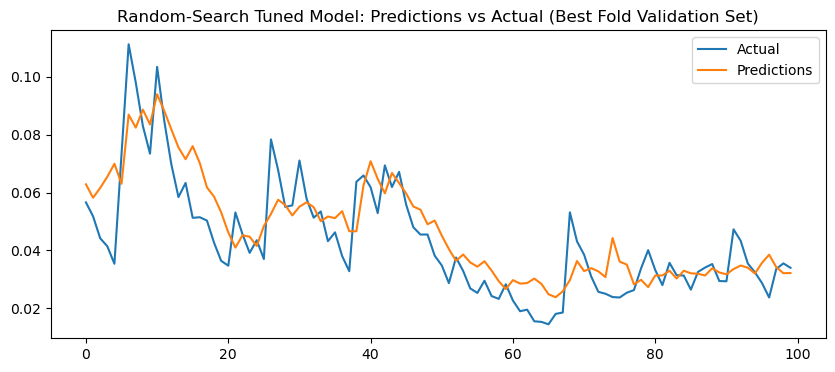

In [34]:
ran_save_path = "models/LSTM/LSTM_random/"
#load the best y-estimation from the random search tuned model model
y_pred_random = np.load(ran_save_path + "random_valPred.npy")
#load the actual val set for that split
y_true_random = np.load(ran_save_path + "random_valTrue.npy")
##Note. this is done as training and validation sets are split due to tscv (in each fold there is a train and a val,
#this keep the best train-val split that got the best evaluation metrics)

#plot actual vs predicted val sets
plt.figure(figsize=(10,4))
plt.plot(y_true_random[:100], label='Actual') #actual
plt.plot(y_pred_random[:100], label='Predictions') #predicted
plt.title('Random-Search Tuned Model: Predictions vs Actual (Best Fold Validation Set)')
plt.legend()
#show it
plt.show()
##Not done on the entire train-split as it is just as a screening-model-assessment

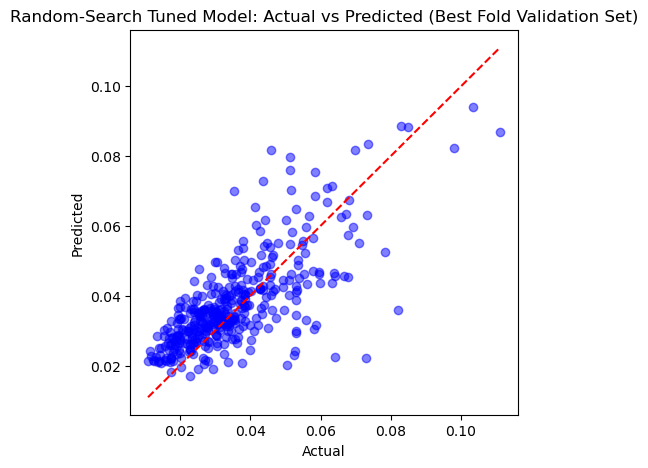

In [27]:
# Scatter plot (identity line)
plt.figure(figsize=(5,5)) #define figure size
#plot the actual vs true as dots
plt.scatter(y_true_random, #x
            y_pred_random, #y
            alpha=0.5, #opacity
            color = "blue")
#draw a 45 degree line based on true value (i.e those on the line are the true values)
plt.plot([min(y_true_random), max(y_true_random)], #x-coordinated for the line (spand from x-true min to x-true max)
         [min(y_true_random), max(y_true_random)], 'r--')  #y-coordinated for the line (spand from x-true min to x-true max)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Random-Search Tuned Model: Actual vs Predicted (Best Fold Validation Set)')
plt.show()

Overall, random search tuning improved the LSTM’s performance: both RMSE and MAE are now below 0.01, and R² exceeds 0.5. Given the high volatility and unpredictability of the target (Bitcoin volatility), these are encouraging results.

Still, with only ~13% of the parameter space explored, it feels like there is room for further refinement.

### BAYESIAN OPTIMIZATION

Bayesian optimization (BO) efficiently finds a model hyperparameters by building a surrogate objective function and selecting promising candidates iteratively. Ideally, it should help in fine-tuning the random search's (RS) top-performing parameters. That's why these are plugged as the starting point (x0) in the BO. 

However, If BO does not improve the results, it suggests that RS was already lucky in finding an almost optimal parameter set.

Let's run the BO to find out.

In [22]:
#define the saving path
# save the best model in the LSTM/LSTM_bayesian/ folder
bay_save_path = "models/LSTM/LSTM_bayesian/"
os.makedirs(bay_save_path, exist_ok=True) #suppress error if it already exists


 Trial 1/100
Testing params: {'units': 128, 'dropout_rate': 0.4, 'l2_lambda': 0.0001, 'learning_rate': 0.0005, 'recurrent_dropout': 0.2, 'batch_size': 64}


2025-09-20 15:26:03.450222: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
📉 Avg RMSE = 0.0164
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
✅ Best model updated and saved (Avg RMSE=0.0164)

 Trial 2/100
Testing params: {'units': 128, 'dropout_rate': 0.17337391594646553, 'l2_lambda': 0.00362561763457623, 'learning_rate': 0.001562069367563987, 'recurrent_dropout': 0.2783331011414365, 'batch_size': 16}
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
📉 Avg RMSE = 0.0160
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
✅ Best model updated and saved (Avg RMSE=0.0160)

 Trial 3/100
Testing params: {'units': 64, 'dropout_rate': 0.23348344445560876, 'l2_lambda': 0.0001930783753654713, 'learning_rate': 0.0020034427927560746, 'recurrent_dropout': 0.12256463161084011, 'batch_size': 64}
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26m

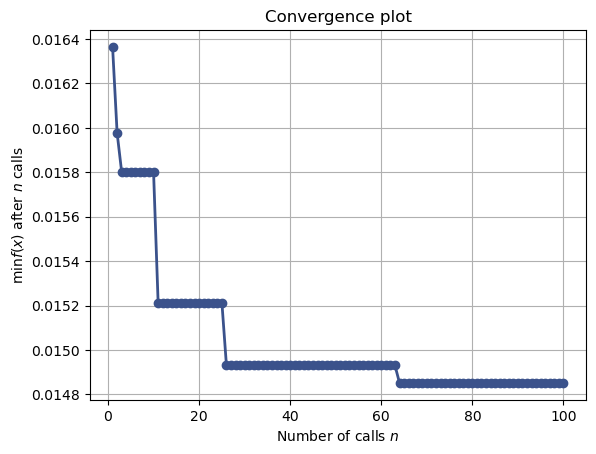

In [26]:
#### BAYESIAN OPTIMIZATION
#set the seed for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# define the parameters' grid
##Note. this time batch_size is tuned too
bay_space = [
    Categorical([32, 64, 96, 128], name='units'),
    Real(0.1, 0.5, name='dropout_rate'),
    Real(1e-4, 1e-2, prior='log-uniform', name='l2_lambda'),
    Real(1e-4, 1e-2, prior='log-uniform', name='learning_rate'),
    Real(0.1, 0.5, name ='recurrent_dropout'),
    Categorical([16, 32, 64], name='batch_size')  
]

#define the best parameters coming from Random Search Tuning
x0 = [
    [128, 0.4, 0.0001, 0.0005, 0.2, 64] #best RS parameters
]
#this will work as a starting point

#define the trial (and the trial counter)
bay_trial_counter = 0 #counts the trial
bay_total_trials = 100 #amount of combinations tested (n_calls later on)

#tracking and storing
bay_best_rmse = np.inf
bay_best_params = None
bay_best_model = None
bay_best_X_val = None
bay_best_y_val = None
bay_best_history = None
bay_all_results = []

# define the function to build a tuned model based on BO
def bay_build_regularized_model(input_shape, units, dropout_rate, l2_lambda, learning_rate, recurrent_dropout):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(int(units), kernel_regularizer=l2(l2_lambda), recurrent_dropout=recurrent_dropout),
        Dropout(dropout_rate),
        Dense(1)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse')
    return model


#Define the objective function
@use_named_args(bay_space) #unpack the params into a dictionary -> keys matching names set in bay space.
def bay_objective(**params):
    global bay_trial_counter
    #set the seed for reproducibility
    tf.random.set_seed(42)
    #count the trial
    bay_trial_counter += 1
    #show the trial number
    print(f"\n Trial {bay_trial_counter}/{bay_total_trials}")
    #and the tested params
    print(f"Testing params: {params}")
    #define the time series split
    tscv = TimeSeriesSplit(n_splits=n_splits)
    #lists to store rmses, models and histories
    fold_rmses = []
    fold_models = []
    fold_val_data = []
    fold_histories = []

    #re-iterate model building for each cv split (defined by n-splits)
    for train_idx, val_idx in tscv.split(X_lstm):
        #split into train-val X and Y
        X_train, X_val = X_lstm[train_idx], X_lstm[val_idx]
        y_train, y_val = y_lstm[train_idx], y_lstm[val_idx]

        #build the model w/ the params grid
        bay_model = bay_build_regularized_model(
            input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
            units=params['units'],
            dropout_rate=params['dropout_rate'],
            recurrent_dropout=params['recurrent_dropout'],
            l2_lambda=params['l2_lambda'],
            learning_rate=params['learning_rate']
        )
        
        #short patience for tuning
        early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

        #fit the model & compile its history
        history = bay_model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=50,
            batch_size=params['batch_size'],
            callbacks=[early_stop],
            verbose=0
        )

        # Predict (w/ inverse scaling)
        y_pred = bay_model.predict(X_val, verbose=1)
        y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
        y_true = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()
        #compute rmse
        fold_rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        #append metrics to its list
        fold_rmses.append(fold_rmse)
        fold_models.append(bay_model)
        fold_val_data.append((X_val, y_val))
        fold_histories.append(history)
    # Average RMSE for this set of params
    bay_avg_rmse = np.mean(fold_rmses)
    #store params - rmse list
    bay_all_results.append({"params": params, "avg_rmse": bay_avg_rmse})
    #and show it
    print(f"📉 Avg RMSE = {bay_avg_rmse:.4f}")

    # Check if this trial is the best AND recursively keep the best params, folds and store it in LSTM_bay
    global bay_best_rmse, bay_best_params, bay_best_model, bay_best_X_val, bay_best_y_val, bay_best_history
    if bay_avg_rmse < bay_best_rmse:
        bay_best_rmse = bay_avg_rmse
        bay_best_params = params
        #identify the best fold in the trial
        best_fold_idx = np.argmin(fold_rmses)
        bay_best_model = fold_models[best_fold_idx]
        bay_best_X_val, bay_best_y_val = fold_val_data[best_fold_idx]
        bay_best_history = fold_histories[best_fold_idx]

        # Save model, folds and history (commented out = already saved)
        bay_best_model.save(bay_save_path + "bay_LSTM.keras")
        np.save(bay_save_path + "bay_valPred.npy", scaler_y.inverse_transform(
            bay_best_model.predict(bay_best_X_val).reshape(-1, 1)).ravel())
        np.save(bay_save_path + "bay_valTrue.npy", scaler_y.inverse_transform(bay_best_y_val.reshape(-1, 1)).ravel())
        np.save(bay_save_path + "bay_history.npy", bay_best_history.history)
        with open(bay_save_path + "bay_best_params.json", "w") as f:
            json.dump(bay_best_params, f)
        #print confirmation
        print(f"✅ Best model updated and saved (Avg RMSE={bay_avg_rmse:.4f})")
    return bay_avg_rmse

#run bayesian optimization
bay_res = gp_minimize(
    func=bay_objective, #model plugged
    dimensions=bay_space, #param grid
    x0 = x0, #starting params
    acq_func='EI',
    n_calls=bay_total_trials, #how many trials (i.e attempts)
    random_state=42 #reproducibility
)

## TOP PERFORMING TRIAL & ITS BEST FOLD
#Prediction w/ the best fold model on its validation data
bay_y_pred = bay_best_model.predict(bay_best_X_val, verbose=0)
bay_y_pred = scaler_y.inverse_transform(bay_y_pred.reshape(-1, 1)).ravel()
bay_y_true = scaler_y.inverse_transform(bay_best_y_val.reshape(-1, 1)).ravel()
#compute evaluation metrics
bay_rmse = np.sqrt(mean_squared_error(bay_y_true, bay_y_pred))
bay_mae = mean_absolute_error(bay_y_true, bay_y_pred)
bay_r2 = r2_score(bay_y_true, bay_y_pred)
#show them
print("Model Validation Metrics (Best Fold):")
print(f"RMSE: {bay_rmse:.4f}")
print(f"MAE : {bay_mae:.4f}")
print(f"R²  : {bay_r2:.4f}")

#show the best model paramters
print("=== Best performing Trial ===")
print("\nBest params found:", bay_best_params)
#along with its training RMSE
print("Best Fold RMSE:", bay_rmse)
#and the best avg rmse
print(f"Best Avg RMSE: {bay_best_rmse:.4f}")

#save the all results
pd.DataFrame(bay_all_results).to_csv(bay_save_path + "bay_all_results.csv", index=False)

#plot the convergence plot
print("======= Show the convergence plot =======")
plot_convergence(bay_res)
plt.show()

Let's now display the predicted-vs-actual time-series plot together with the corresponding scatterplot to asses the model's performances.

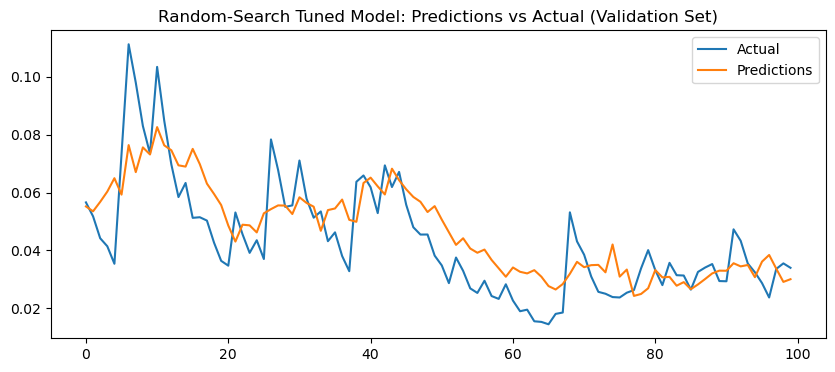

In [31]:
bay_save_path = "models/LSTM/LSTM_bayesian/"
#load the best y-estimation from the BO model
y_pred_bay = np.load(bay_save_path + "bay_valPred.npy")
#load the actuals val set for that split
y_true_bay = np.load(bay_save_path + "bay_valTrue.npy")
##Note. this is done as training and validation sets are split due to tscv (in each fold there is a train and a val,
#this keep the best train-val split that got the best evaluation metrics)

#plot actual vs predicted val sets
plt.figure(figsize=(10,4))
plt.plot(y_true_bay[:100], label='Actual')
plt.plot(y_pred_bay[:100], label='Predictions')
plt.title('Random-Search Tuned Model: Predictions vs Actual (Validation Set)')
plt.legend()
#show it
plt.show()
##Not done on the entire train-split as it is just as a screening-model-assessment

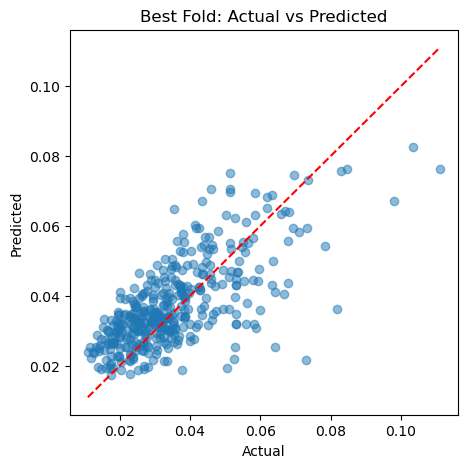

In [28]:
# Scatter plot (identity line)
plt.figure(figsize=(5,5))
plt.scatter(y_true_bay, y_pred_bay, alpha=0.5)
plt.plot([min(y_true_bay), max(y_true_bay)],
         [min(y_true_bay), max(y_true_bay)], 'r--')  # 45° line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Best Fold: Actual vs Predicted')
plt.show()

At first sight, the BO does not give the impression to enhance upon RS' otucomes. Although it still yeilds strong performances, the metrics seem a slightly off than those from RS.

Let's compare the two directly.

### TUNED MODELS COMPARISON

Random Search model performances (top fold):
RMSE: 0.0110
MAE : 0.0084
R²  : 0.4906
------------------------------------------
Bayesian model performances (top fold):
RMSE: 0.0114
MAE : 0.0088
R²  : 0.4576
------------------------------------------

Predicted vs Actual plot: RS vs BO
-----------------------------------


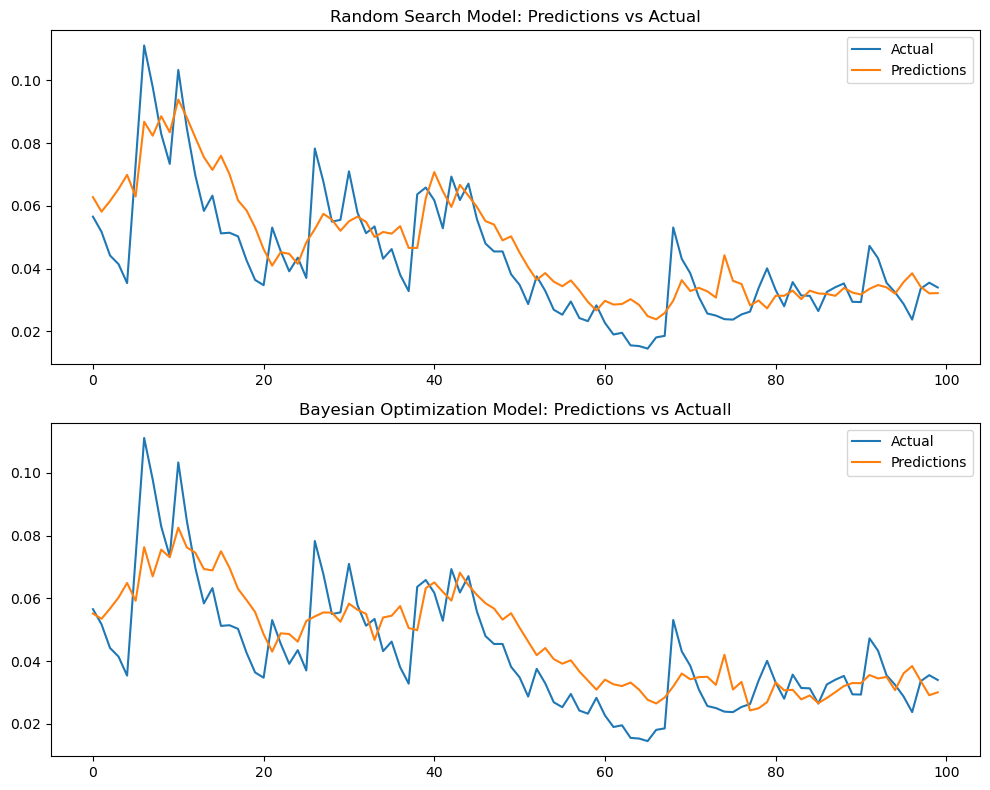

In [39]:
# === Load saved predictions ===
ran_save_path = "models/LSTM/LSTM_random/"
bay_save_path = "models/LSTM/LSTM_bayesian/"

# Random Search
y_true_random = np.load(ran_save_path + "random_valTrue.npy")
y_pred_random = np.load(ran_save_path + "random_valPred.npy")

# Bayesian Optimization
y_true_bay = np.load(bay_save_path + "bay_valTrue.npy")
y_pred_bay = np.load(bay_save_path + "bay_valPred.npy")

# === Model Comparison - evaluation metrics ===
print("Random Search model performances (top fold):")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_random, y_pred_random)):.4f}")
print(f"MAE : {mean_absolute_error(y_true_random, y_pred_random):.4f}")
print(f"R²  : {r2_score(y_true_random, y_pred_random):.4f}")
print("------------------------------------------")

print("Bayesian model performances (top fold):")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_bay, y_pred_bay)):.4f}")
print(f"MAE : {mean_absolute_error(y_true_bay, y_pred_bay):.4f}")
print(f"R²  : {r2_score(y_true_bay, y_pred_bay):.4f}")
print("------------------------------------------")

# Model comparison - actual vs predicted charts
### FIX CODE
# show the plots together
#random plot
#define fig and axis
fig1, ax1 = plt.subplots()
#build the fig as above
ax1.plot(y_true_random[:100], label='Actual')
ax1.plot(y_pred_random[:100], label='Predictions')
ax1.set_title("Random Search Model: Predictions vs Actual")
ax1.legend()
#store the axis
regularized_plot = ax1
#avoid showing it
plt.close(fig1)

#bayesia plot
#define fig and axis
fig2, ax2 = plt.subplots()
#build the fig as above
ax2.plot(y_true_bay[:100], label='Actual')
ax2.plot(y_pred_bay[:100], label='Predictions')
ax2.set_title("Bayesian Optimization Model: Predictions vs Actual")
ax2.legend()
#store the axis
stacked_plot = ax2
#avoid displaying it
plt.close(fig2)

#give a title
print("")
print("Predicted vs Actual plot: RS vs BO")
print("-----------------------------------")
#define the layout
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 8))
# Copy content from stored plots
#regularized
for line in regularized_plot.lines:
    ax_top.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
ax_top.set_title("Random Search Model: Predictions vs Actual")
ax_top.legend()
#stacked
for line in stacked_plot.lines:
    ax_bottom.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
ax_bottom.set_title("Bayesian Optimization Model: Predictions vs Actuall")
ax_bottom.legend()
#show them
plt.tight_layout()
plt.show()


Generally, BO does not appear to improve upon the RS' outcomes. The identical best-trial average RMSE (0.0149) coupled with its slightly weaker top-fold model's perfromances support this claim. Furthermore, the actual-vs-predicted plots highlights how smoother is the RS model in catching more up-and-downs. 
Altogether, these findings point to the BO's struggle in fine-tuning hyperparameters already close to optimal, which the RS (randomly) happened to identify.

The bottom line is it makes sense to move forward with the RS' hyperparameters. Therefore, an LSTM with these settings will be re-trained and evaluated on the validation set. For the sake of clarity, the chosen parameters are listed here:

In [22]:
# Load RS best params
with open(ran_save_path + "random_best_params.json", "r") as f:
    ran_best_params = json.load(f)
#add recurrent_dropout = 0.2 (as in tuning)
ran_best_params["recurrent_dropout"] = 0.2
#show them
print(" ")
print("===== RS best parameters: =====")
print(" ")
for key, value in ran_best_params.items():
    print(f"{key}: {value}")
print(" ")

 
===== RS best parameters: =====
 
units: 128
dropout_rate: 0.4
l2_lambda: 0.0001
learning_rate: 0.0005
batch_size: 64
recurrent_dropout: 0.2
 


## TOP-PERFORMING MODEL: FINAL ASSESSMENTS

In [23]:
#define the path for the final-tuned model
final_save_path = "models/LSTM/LSTM_champion/"
os.makedirs(final_save_path, exist_ok=True)

### FINAL VALIDATION

Once selected the hyperparameters, it is time to train the model again. To perform a fair final validation, cross-validation splits are kept and the evaluation metrics are computed on the last fold's validation set.

This procedure should give confidence about the parameters' generalization capacities.

Note. recurrent dropout is set manually to 0.2 since it is not included in ran_best_param (was not tuned during RS).

In [24]:
#call again the function for the tuned model (if the top-performing model has been loaded)
#Note. recurrent dropout is set to 0.2 already
def tuned_regularized_model(input_shape, units, dropout_rate, l2_lambda, learning_rate):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(units,
             kernel_regularizer=l2(l2_lambda),
             recurrent_dropout=0.2), #recurrent dropout already defined
        Dropout(dropout_rate),
        Dense(1)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="mse")
    return model

In [25]:
#Top model re-train w/ cv folds

#set the seed for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

#define the time series split
tscv = TimeSeriesSplit(n_splits=n_splits)

# Initialize lists to collect metrics per fold
rmse_scores_val, mae_scores_val, r2_scores_val = [], [], []

# Loop through the various CV splits
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_lstm), 1):
    print(f"\n===== Split number: {fold} =====")
    #split into training and validation fold
    X_train, X_val = X_lstm[train_idx], X_lstm[val_idx]
    y_train, y_val = y_lstm[train_idx], y_lstm[val_idx]
    
    #define the validation model (params unpacked from the top-performing model)
    val_LSTM = tuned_regularized_model(
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
        units=ran_best_params["units"],
        dropout_rate=ran_best_params["dropout_rate"],
        l2_lambda=ran_best_params["l2_lambda"],
        learning_rate=ran_best_params["learning_rate"]
    )
    #define an early stopping (as w/ reg and stacked model)
    final_early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    #fit the model
    LSTM_history_val = val_LSTM.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=ran_best_params["batch_size"],
        callbacks=[final_early_stop],
        verbose=1
    )
    # Prediction (inverse scaled)
    y_pred_val = val_LSTM.predict(X_val)
    y_pred_val = scaler_y.inverse_transform(y_pred_val.reshape(-1, 1)).ravel()
    y_true_val = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()
    
    # Metrics
    rmse_val = np.sqrt(mean_squared_error(y_true_val, y_pred_val))
    mae_val = mean_absolute_error(y_true_val, y_pred_val)
    r2_val = r2_score(y_true_val, y_pred_val)
    
    print("\nFinal Validation Metrics:")
    print("---------------------------")
    print(f"RMSE: {rmse_val:.4f}")
    print(f"MAE : {mae_val:.4f}")
    print(f"R²  : {r2_val:.4f}")

    # Append metrics
    rmse_scores_val.append(rmse_val)
    mae_scores_val.append(mae_val)
    r2_scores_val.append(r2_val)


===== Split number: 1 =====
Epoch 1/100


2025-10-22 13:07:17.506684: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 100ms/step - loss: 0.6873 - val_loss: 1.9250
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.5107 - val_loss: 1.6675
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.4304 - val_loss: 1.5347
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3481 - val_loss: 1.4581
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3509 - val_loss: 1.4081
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3839 - val_loss: 1.3586
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.3074 - val_loss: 1.3385
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.3308 - val_loss: 1.3257
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.3222 - val_loss: 1.2752
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.2925 - val_loss: 1.2576
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2866 - val_loss: 1.2240
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.2971 - val_loss: 1.2041


In [29]:
# Compute the average metrics for the cv training
print("\n===== Cross-Validation Last-fold Metrics =====")
print(f"Last-fold RMSE: {rmse_scores_val[2]:.4f}")
print(f"Last-fold MAE : {mae_scores_val[2]:.4f}")
print(f"Last-fold R²  : {r2_scores_val[2]:.4f}")


===== Cross-Validation Last-fold Metrics =====
Last-fold RMSE: 0.0117
Last-fold MAE : 0.0088
Last-fold R²  : 0.4258


As foreeseable, evaluation metrics on the folded final model are slightly worse than the top-fold model's ones. This difference is not a big deal, since randomness naturally casuses fluctuations. What truly matters is the results' closeness, which suggests the model is robust and does a nice job in generalizating to unseen data.

To further test the model's robustness, white noise is added to the data and performances are compared once more.

### ROBUSTNESS TESTING: WHITE NOISE ADDITION

Even if smoothed, financial time series are inherently noisy. Small shocks and unpredictable fluctuations are quite frequent in this kind of data. 
Injecting controlled white noise during training forces the LSTM to focus on on learning the underlying data's structure rather than memorizing exact patterns. This not only improves robustness, but also prevents overfitting.

Let's add white noise having different variance (from 0.00 to 0.50) to the top-performing LSTM to check if its performances improve.

In [28]:
#Define a function for a model accepting white noise
#Note. same as above + add_white_noise
def wn_regularized_model(input_shape, units, dropout_rate, l2_lambda, learning_rate, recurrent_dropout, add_white_noise=False, noise_std=0.01):
    model = Sequential()
    model.add(Input(shape=input_shape))

    # noise only if requested (noise_std defines noise's variance)
    if add_white_noise:
        model.add(GaussianNoise(noise_std)) 
    
    model.add(LSTM(
        units,
        kernel_regularizer=l2(l2_lambda),
        #not tuned
        recurrent_dropout=recurrent_dropout
    ))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="mse")
    return model


In [28]:
#WHITE NOISE MODEL w/ CV

#set the seed for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

#define the time series split
tscv = TimeSeriesSplit(n_splits=n_splits)
#set a loop to go through the various cv splits
for train_idx, val_idx in tscv.split(X_lstm):
    pass  # after the loop, leave the last split (the evalution metrics are computed just on that)
#split into training and validation fold
X_train, X_val = X_lstm[train_idx], X_lstm[val_idx]
y_train, y_val = y_lstm[train_idx], y_lstm[val_idx]

#dictionary to store the result for comparison
wn_res = {}

#define a loop to test different noise's standard deviation
for noise_std in [0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1]:
    print("")
    print(f"Model w/ white noise = {noise_std}:")
    print("------------------------------------")
    
#define the validation model (params unpacked from the top-performing model)
    wn_LSTM = wn_regularized_model(
        add_white_noise=True, #add white noise
        noise_std = noise_std, #define white noise variance
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
        units=ran_best_params["units"],
        dropout_rate=ran_best_params["dropout_rate"],
        l2_lambda=ran_best_params["l2_lambda"],
        learning_rate=ran_best_params["learning_rate"],
        recurrent_dropout=ran_best_params["recurrent_dropout"]
    )
    #early stopping is as before   
    final_early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
    #fit the model
    wn_LSTM_history = wn_LSTM.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=100,
        batch_size=ran_best_params["batch_size"],
        callbacks=[final_early_stop],
        verbose=1
    )
    # Prediction (inverse scaled)
    y_pred_wn = wn_LSTM.predict(X_val)
    y_pred_wn = scaler_y.inverse_transform(y_pred_wn.reshape(-1, 1)).ravel()
    y_true_wn = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()
    
    # Metrics
    rmse_wn = np.sqrt(mean_squared_error(y_true_wn, y_pred_wn))
    mae_wn = mean_absolute_error(y_true_wn, y_pred_wn)
    r2_wn = r2_score(y_true_wn, y_pred_wn)
    #show the metrics
    print(f"\nFinal Validation Metrics for {noise_std:.2f}:")
    print("---------------------------")
    print(f"RMSE: {rmse_wn:.4f}")
    print(f"MAE : {mae_wn:.4f}")
    print(f"R²  : {r2_wn:.4f}")
    #save it in a dictionary
    wn_res[noise_std] = [rmse_wn, mae_wn, r2_wn]


Model w/ white noise = 0.0:
------------------------------------
Epoch 1/100


2025-10-03 17:47:57.187131: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 70ms/step - loss: 1.2092 - val_loss: 0.4913
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.8596 - val_loss: 0.4082
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 0.7514 - val_loss: 0.3420
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 0.6476 - val_loss: 0.3372
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.6628 - val_loss: 0.3242
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.5898 - val_loss: 0.3276
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - loss: 0.5626 - val_loss: 0.3160
Epoch 8/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.5468 - val_loss: 0.3437
Epoch 9/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 0.4648 - val_loss: 0.3264
Epoch 10/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - loss: 0.5066 - val_loss: 0.3340
Epoch 11/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4528 - val_loss: 0.3227
Epoch 12/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - loss: 0.4

In [26]:
#Show the results for different white-noise level
dec = 4
#round each metric inside the list
wn_res_round = {key: [round(val, dec) for val in wn_res[key]] for key in wn_res}
wn_res_round

{0.0: [0.0119, 0.0093, 0.4084],
 0.01: [0.0116, 0.0088, 0.4341],
 0.02: [0.0113, 0.0083, 0.4627],
 0.03: [0.011, 0.008, 0.4924],
 0.04: [0.011, 0.0079, 0.4964],
 0.05: [0.0119, 0.009, 0.4056],
 0.06: [0.0108, 0.0079, 0.508],
 0.07: [0.0115, 0.0086, 0.4437],
 0.08: [0.011, 0.0081, 0.4944],
 0.09: [0.0117, 0.0093, 0.4255],
 0.1: [0.0116, 0.0087, 0.4359]}

After testing different white noise levels, the model with variance = 0.06 outperformed all the other LSTMs. This shows that the model became more robust in predicting unseen data. Therefore, it is reasonable to add white noise the to model.

Although the gains suggest that the exisiting params are robust enough, adding a GaussianNoise layer changes both the optimal parameters combination and the optimization landscape. In other words, the parameters set found by RS may no longer be the true top-performing one. As a consequence, it is reasonable to run a RS re-tuning (100 trials) to double check whether the model can be fined-tuned further.

In [27]:
#add the noise_std to the random best param dictionary (Paramters from the first RS)
ran_best_params["noise_std"] = 0.06
#check it (if nothing is printed, then it is properly added)
if ran_best_params["noise_std"] != 0.06:
    print("Noise_std wrongly added")

#### LIGHT RE-TUNING

To fine-tune the model with white noise, the same random search strategy used during the main hyperparameters tuning phase is applied. However, to balance throughness with computational efficiency, the search was limited to 30 trials instead of a larger sweep (100).

In [32]:
## RANDOM SEARCH TUNING WITH WHITE NOISE

# set the seed for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

# define the parameters grid (same as before + noise_std)
param_grid = {
    "units": [32, 64, 96, 128],
    "dropout_rate": [0.1, 0.2, 0.3, 0.4, 0.5],
    "recurrent_dropout": [0.1, 0.2, 0.3, 0.4, 0.5],
    "l2_lambda": [0.0001, 0.001, 0.01],
    "learning_rate": [1e-4, 5e-4, 1e-3, 5e-3],
    "batch_size": [16, 32, 64],
    "noise_std": [0.0, 0.02, 0.04, 0.05, 0.06, 0.08, 0.1]
}

# define trials, runs per trial (smaller since we already know good params)
n_trials = 100   # lighter RS
n_runs_rs = 1   # as before

# tracking and storing
best_avg_rmse = np.inf
best_params = None
best_fold_rmse = np.inf
best_fold_model = None
best_X_val = None
best_y_val = None
best_fold_history = None

# function for white-noise model
def wn_regularized_model(input_shape, units, dropout_rate, l2_lambda, learning_rate, recurrent_dropout, noise_std=0.0):
    model = Sequential([
        Input(shape=input_shape),
        GaussianNoise(noise_std),  # always included, even if noise_std=0.0
        LSTM(units,
             kernel_regularizer=l2(l2_lambda),
             recurrent_dropout=recurrent_dropout),
        Dropout(dropout_rate),
        Dense(1)
    ])
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss="mse")
    return model

# Build the code for the random search
for trial in range(n_trials):
    print(f"\n=== Trial {trial + 1}/{n_trials} ===")

    # randomly sample params
    params = {k: random.choice(v) for k, v in param_grid.items()}
    print("Params:", params)

    trial_rmses, trial_models, trial_val_data, trial_histories = [], [], [], []

    for run in range(n_runs_rs):
        print(f"\n=== Run {run + 1}/{n_runs_rs} ===")
        tscv = TimeSeriesSplit(n_splits=n_splits)

        for train_idx, val_idx in tscv.split(X_lstm):
            X_train, X_val = X_lstm[train_idx], X_lstm[val_idx]
            y_train, y_val = y_lstm[train_idx], y_lstm[val_idx]

            early_stop_tune = EarlyStopping(
                monitor="val_loss", patience=3, restore_best_weights=True
            )

            model = wn_regularized_model(
                input_shape=(X_lstm.shape[1], X_lstm.shape[2]),
                units=params["units"],
                dropout_rate=params["dropout_rate"],
                l2_lambda=params["l2_lambda"],
                learning_rate=params["learning_rate"],
                noise_std=params["noise_std"],  # inject noise
                recurrent_dropout=params["recurrent_dropout"]
            )

            history = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=50,
                batch_size=params["batch_size"],
                callbacks=[early_stop_tune],
                verbose=0
            )

            y_pred = scaler_y.inverse_transform(model.predict(X_val).reshape(-1, 1)).ravel()
            y_true = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel()

            rmse = np.sqrt(mean_squared_error(y_true, y_pred))
            trial_rmses.append(rmse)
            trial_models.append(model)
            trial_val_data.append((X_val, y_val))
            trial_histories.append(history)

    ran_avg_rmse = np.mean(trial_rmses)
    print(f"Avg RMSE = {ran_avg_rmse:.4f}")

    # Check if this trial is the best
    if ran_avg_rmse < best_avg_rmse:
        best_avg_rmse = ran_avg_rmse
        best_params = params
        best_fold_idx = np.argmin(trial_rmses)
        best_fold_rmse = trial_rmses[best_fold_idx]
        best_fold_model = trial_models[best_fold_idx]
        best_X_val, best_y_val = trial_val_data[best_fold_idx]
        best_fold_history = trial_histories[best_fold_idx]

        # save best noisy model
        best_fold_model.save(ran_save_path + "random_wn_LSTM.keras")
        np.save(ran_save_path + "random_wn_valPred.npy", scaler_y.inverse_transform(best_fold_model.predict(best_X_val).reshape(-1, 1)).ravel())
        np.save(ran_save_path + "random_wn_valTrue.npy", scaler_y.inverse_transform(best_y_val.reshape(-1, 1)).ravel())
        np.save(ran_save_path + "random_wn_history.npy", best_fold_history.history)
        with open(ran_save_path + "random_wn_best_params.json", "w") as f:
            json.dump(best_params, f)
        print("--- Best trial updated and saved.")

## TOP-PERFORMING TRIAL & ITS BEST FOLD
y_pred = best_fold_model.predict(best_X_val)
y_pred = scaler_y.inverse_transform(y_pred.reshape(-1, 1)).ravel()
y_true = scaler_y.inverse_transform(best_y_val.reshape(-1, 1)).ravel()

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print("Model Validation Metrics (Best Fold):")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R²  : {r2:.4f}")

print("\n=== Random Search Best Trial (with Noise) ===")
print("Best trial params:", best_params)
print(f"Best trial average RMSE: {best_avg_rmse:.4f}")
print(f"Best fold RMSE: {best_fold_rmse:.4f}")
print(f"Best fold metrics -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}")



=== Trial 1/100 ===
Params: {'units': 32, 'dropout_rate': 0.1, 'recurrent_dropout': 0.3, 'l2_lambda': 0.0001, 'learning_rate': 0.0005, 'batch_size': 16, 'noise_std': 0.08}

=== Run 1/1 ===
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Avg RMSE = 0.0153
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
--- Best trial updated and saved.

=== Trial 2/100 ===
Params: {'units': 128, 'dropout_rate': 0.2, 'recurrent_dropout': 0.4, 'l2_lambda': 0.01, 'learning_rate': 0.001, 'batch_size': 16, 'noise_std': 0.1}

=== Run 1/1 ===
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step
Avg RMSE = 0.0164

=== Trial 3/100 ===
Params: {'units': 96, 'dropout_rate': 0.1, 'recurrent_dropout': 0.4, 'l2_lambda': 0.01, 'learning_rate': 0.0001, 'batch_size': 32, 'noise_std': 0.0}

=== Run 1/1 ===
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
13/13 

The light re-tuning procedure identified a different set of hyperparameters compared to the original optimal combination. On the CV folds, this new setup achieved slightly stronger performance than the earlier best model (RMSE 0.0106 vs. 0.0108; MAE 0.0078 vs. 0.0079; R² 0.5249 vs. 0.508). This suggests that adding white noise reshaped the optimization landscape, revealing a different optimal region in the parameter space.

Nevertheless, since the improvements are marginal, both configurations will be carried forward to the final validation and evaluation phase to test which model generalizes more effectively.

In [30]:
# Load RS best params
with open(ran_save_path + "random_wn_best_params.json", "r") as f:
    wn_ran_best_params = json.load(f)
#show them
print(" ")
print("===== Light-tuning RS best parameters: =====")
print(" ")
for key, value in wn_ran_best_params.items():
    print(f"{key}: {value}")
print(" ")

 
===== Light-tuning RS best parameters: =====
 
units: 128
dropout_rate: 0.4
recurrent_dropout: 0.5
l2_lambda: 0.001
learning_rate: 0.001
batch_size: 16
noise_std: 0.1
 


# CHAMPION MODEL: FINAL VALIDATION & EVALUATION

To choose the final model, a two-steps procedure is followed for both model:

- **CV robustness check**: the model is re-trained using cross-validation, with the last fold serving as validation. This acts as a robustness check, ensuring the selected parameters + white noise layer perform consistently across different splits rather than relying on just one favorable fold.
- **Hold-out evaluation**: After confirming stability, the model is re-trained on the full training set with the same parameter configuration. The final evaluation is then performed on the held-out validation set, which has never been used during training. This guarantees that the reported results reflect true out-of-sample generalizations.

Finally, two complementary comparisons are made:

- **Intra-model**: each model is examined for stability by comparing its performances between CV and the final hold-out set. A significant drop in results points to potential overfitting and/or weak generalization.
- **Inter-model**: the two model are directly compared on the hold-out valuation. The model outperforming the other will be selected as the champion model.

Let's begin with the paramters combination coming from the first RS + white noise.

#### BEST HYPERPARM: RS + WHITE NOISE

As a refresher, let's display parameters the first RS selected along with its white noise level.

In [31]:
ran_best_params

{'units': 128,
 'dropout_rate': 0.4,
 'l2_lambda': 0.0001,
 'learning_rate': 0.0005,
 'batch_size': 64,
 'recurrent_dropout': 0.2,
 'noise_std': 0.06}

Then, the first step is to fit the model with the cross-validation folds and display its outcomes.

In [29]:
# RS + white noise model cv robustness check
#tscv used again in the training phase

# set the seed for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

##define a longer early stopping (as w/ reg and stacked model) 
val_early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True) 

#define the list to appen the metrics
ranlist_rmse,  ranlist_mae, ranlist_r2 = [], [], []

#descritpion
print("")
print("Top-performing model + white noise final validation:")
print("----------------------------------------------------")

#define the time series split
tscv = TimeSeriesSplit(n_splits=n_splits) 
#set a loop to go through the various cv splits
for train_idx, val_idx in tscv.split(X_lstm): 
    #split into training and validation fold 
    X_train, X_val = X_lstm[train_idx], X_lstm[val_idx] 
    y_train, y_val = y_lstm[train_idx], y_lstm[val_idx] 
    
#define the validation model (params unpacked from the top-performing model + white noise) 
    ran_val_LSTM = wn_regularized_model(
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]), 
        add_white_noise=True, #add white noise
        noise_std = ran_best_params["noise_std"], #define white noise variance
        units=ran_best_params["units"], 
        dropout_rate=ran_best_params["dropout_rate"], 
        l2_lambda=ran_best_params["l2_lambda"], 
        learning_rate=ran_best_params["learning_rate"],
        recurrent_dropout = ran_best_params["recurrent_dropout"]
    ) 
    
    #fit the model 
    ran_val_LSTM_history = ran_val_LSTM.fit(X_train, 
                                    y_train, 
                                    validation_data=(X_val, y_val), 
                                    epochs=100, 
                                    batch_size=ran_best_params["batch_size"], 
                                    callbacks=[val_early_stop], 
                                    verbose=1 ) 
    
    # Prediction (inverse scaled) 
    print("")
    print("Predicting:")
    y_pred_ranval = ran_val_LSTM.predict(X_val) 
    y_pred_ranval = scaler_y.inverse_transform(y_pred_ranval.reshape(-1, 1)).ravel() 
    y_true_ranval = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel() 
    # Metrics 
    rmse_ranval = np.sqrt(mean_squared_error(y_true_ranval, y_pred_ranval)) 
    mae_ranval = mean_absolute_error(y_true_ranval, y_pred_ranval) 
    r2_ranval = r2_score(y_true_ranval, y_pred_ranval)
    #show them
    print("\nCV robustness check Validation Metrics:")
    print(f"RMSE: {rmse_ranval:.4f}")
    print(f"MAE : {mae_ranval:.4f}")
    print(f"R²  : {r2_ranval:.4f}")
    print("")
    #appen to the metrics to the related list
    ranlist_rmse.append(rmse_ranval)
    ranlist_mae.append(mae_ranval)
    ranlist_r2.append(r2_ranval)

#show average to evaluate the model:
# Compute the average metrics for the cv training
print("\n===== Cross-Validation Average Metrics =====")
print(f"Average RMSE: {np.mean(ranlist_rmse):.4f}")
print(f"Average MAE : {np.mean(ranlist_mae):.4f}")
print(f"Average R²  : {np.mean(ranlist_r2):.4f}")


Top-performing model + white noise final validation:
----------------------------------------------------
Epoch 1/100


2025-10-22 21:33:43.013242: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - loss: 0.6318 - val_loss: 1.9037
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.5131 - val_loss: 1.7653
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3718 - val_loss: 1.6050
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3673 - val_loss: 1.5788
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.3498 - val_loss: 1.4798
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.3406 - val_loss: 1.4373
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3430 - val_loss: 1.4003
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3464 - val_loss: 1.3532
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.3264 - val_loss: 1.3185
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.3111 - val_loss: 1.2949
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.2891 - val_loss: 1.2652
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.2967 - val_loss: 1.2448
E

The cross-validation robustness check produced average metrics (RMSE 0.0151, MAE 0.0097, R² 0.4478) that are close to those obtained during the initial RS + white-noise model testing (RMSE 0.0108, MAE 0.0079, R² 0.508), which used only the last time-series split. This consistency shows the model’s predictive performance's stability across different data splits. Minor variations are expected due to training stochasticity and data variability.

Overall, the evidence so far suggests that the LSTM learned patterns that can generalize beyond the training folds. The next step is to confirm this generalization on the truly unseen data: the held-out validation set.

In [32]:
# Final hold-out evaluation
# Top-performing model re-training

# set the seed for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

#descritpion
print("")
print("Top-performing model + white noise final evaluation:")
print("----------------------------------------------------")
    
#define the evaluation model (params unpacked from the top-performing model + white noise) 
ran_ev_LSTM = wn_regularized_model(
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]), 
        add_white_noise=True, #add white noise
        noise_std = ran_best_params["noise_std"], #define white noise variance
        units=ran_best_params["units"], 
        dropout_rate=ran_best_params["dropout_rate"], 
        l2_lambda=ran_best_params["l2_lambda"], 
        learning_rate=ran_best_params["learning_rate"],
        recurrent_dropout = ran_best_params["recurrent_dropout"]
    ) 
    
#define a longer early stopping (as w/ reg and stacked model) 
ev_early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True) 

#fit the evaluation model 
ran_ev_LSTM_history = ran_ev_LSTM.fit(X_lstm, 
                                y_lstm, 
                                validation_data=(X_lstm_val, y_lstm_val), 
                                epochs=200, 
                                batch_size=ran_best_params["batch_size"], 
                                callbacks=[ev_early_stop], 
                                verbose=1) 

# Prediction (inverse scaled) 
print("")
print("Predicting:")
y_pred_ranev = ran_ev_LSTM.predict(X_lstm_val) 
y_pred_ranev = scaler_y.inverse_transform(y_pred_ranev.reshape(-1, 1)).ravel() 
y_true_ranev = scaler_y.inverse_transform(y_lstm_val.reshape(-1, 1)).ravel() 
# Metrics 
rmse_ranev = np.sqrt(mean_squared_error(y_true_ranev, y_pred_ranev)) 
mae_ranev = mean_absolute_error(y_true_ranev, y_pred_ranev) 
r2_ranev = r2_score(y_true_ranev, y_pred_ranev)
#show them
print("\nHeld-out set final Validation Metrics:")
print(f"RMSE: {rmse_ranev:.4f}")
print(f"MAE : {mae_ranev:.4f}")
print(f"R²  : {r2_ranev:.4f}")


Top-performing model + white noise final evaluation:
----------------------------------------------------
Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 82ms/step - loss: 0.9795 - val_loss: 1.7520
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - loss: 0.6433 - val_loss: 1.7194
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.5550 - val_loss: 1.4204
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - loss: 0.5219 - val_loss: 1.3747
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.4902 - val_loss: 1.3737
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - loss: 0.4415 - val_loss: 1.1838
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.4455 - val_loss: 1.1870
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - loss: 0.4052 - val_loss: 1.0884
Epoch 9/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - loss: 0.3859 - val_loss: 1.0368
Epoch 10/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - loss: 0.4048 - val_loss: 1.0501
Epoch 11/200
25/25 ━━━━━━━━━━━━━

Text(0.5, 1.0, 'Top-performing model: actual-vs-predicted plot (validation set)')

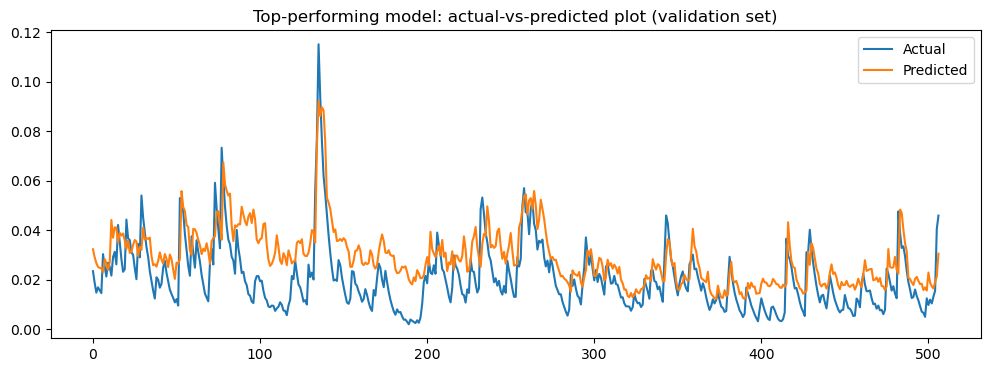

In [40]:
#Actual vs predicted plot (validation set)
plt.figure(figsize=(12,4))
plt.plot(y_true_ranev, label='Actual')
plt.plot(y_pred_ranev, label='Predicted')
plt.legend(); plt.title('RS + WN top-performing model: actual-vs-predicted plot (validation set)')

As expected, the held-out validation set yields slightly weaker metrics (RMSE 0.0124, MAE 0.0104, R² 0.1360) compared to the cross-validation robustness check (RMSE 0.0151, MAE 0.0097, R² 0.4478). While the drop in R² is noticeable, the error magnitude remain similar, showing that the model retains a reasonable level of predictive accuracy. The actual-vs-predicted plot further supports this claim. 

All in all, the outcomes suggest that the LSTM generalizes beyond the training folds, though with some explanatory power loss on entirely unseen data.

#### BEST HYPERPARM: LIGHT TUNING

As a refresher, let's display parameters the final light-tuning highlighted along with its white noise level.

In [31]:
wn_ran_best_params

{'units': 128,
 'dropout_rate': 0.4,
 'recurrent_dropout': 0.5,
 'l2_lambda': 0.001,
 'learning_rate': 0.001,
 'batch_size': 16,
 'noise_std': 0.1}

Then, as done above, let's fit the model with the cross-validation folds and display its outcomes.

In [32]:
# Light Tuning model cv robustness check
#tscv used again in the training phase

# set the seed for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

#descritpion
print("")
print("Light-tuning Top-performing model final validation:")
print("----------------------------------------------------")

#define the lists for storing
wnlist_rmse, wnlist_mae, wnlist_r2 = [] , [], []

#define a longer early stopping (as w/ reg and stacked model) 
val_early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True) 

#define the time series split
tscv = TimeSeriesSplit(n_splits=n_splits) 

#set a loop to go through the various cv splits
for train_idx, val_idx in tscv.split(X_lstm): 
#split into training and validation fold 
    X_train, X_val = X_lstm[train_idx], X_lstm[val_idx] 
    y_train, y_val = y_lstm[train_idx], y_lstm[val_idx] 
    
#define the validation model (params unpacked from the top-performing model + white noise) 
    wn_ran_val_LSTM = wn_regularized_model(
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]), 
        add_white_noise=True, #add white noise
        noise_std = wn_ran_best_params["noise_std"], #define white noise variance
        units=wn_ran_best_params["units"], 
        dropout_rate=wn_ran_best_params["dropout_rate"], 
        l2_lambda=wn_ran_best_params["l2_lambda"], 
        learning_rate=wn_ran_best_params["learning_rate"],
        recurrent_dropout = wn_ran_best_params["recurrent_dropout"]
    ) 
    
    #fit the model 
    wn_ran_val_LSTM_history = wn_ran_val_LSTM.fit(X_train, 
                                    y_train, 
                                    validation_data=(X_val, y_val), 
                                    epochs=100, 
                                    batch_size=wn_ran_best_params["batch_size"], 
                                    callbacks=[val_early_stop], 
                                    verbose=1 ) 
    
    # Prediction (inverse scaled) 
    print("")
    print("Predicting:")
    y_pred_wnval = wn_ran_val_LSTM.predict(X_val) 
    y_pred_wnval = scaler_y.inverse_transform(y_pred_wnval.reshape(-1, 1)).ravel() 
    y_true_wnval = scaler_y.inverse_transform(y_val.reshape(-1, 1)).ravel() 
    # Metrics 
    rmse_wnval = np.sqrt(mean_squared_error(y_true_wnval, y_pred_wnval)) 
    mae_wnval = mean_absolute_error(y_true_wnval, y_pred_wnval) 
    r2_wnval = r2_score(y_true_wnval, y_pred_wnval)
    #show them
    print("\nCV robustness check Validation Metrics:")
    print(f"RMSE: {rmse_wnval:.4f}")
    print(f"MAE : {mae_wnval:.4f}")
    print(f"R²  : {r2_wnval:.4f}")
    print("")
    #append to the metrics to the related list
    wnlist_rmse.append(rmse_wnval)
    wnlist_mae.append(mae_wnval)
    wnlist_r2.append(r2_wnval)

#show average to evaluate the model:
print("\n===== Cross-Validation Average Metrics =====")
print(f"Average RMSE: {np.mean(wnlist_rmse):.4f}")
print(f"Average MAE : {np.mean(wnlist_mae):.4f}")
print(f"Average R²  : {np.mean(wnlist_r2):.4f}")


Light-tuning Top-performing model final validation:
----------------------------------------------------
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - loss: 0.5730 - val_loss: 1.7001
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.4371 - val_loss: 1.3219
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.3804 - val_loss: 1.1651
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.3033 - val_loss: 1.0829
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.3088 - val_loss: 1.0424
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2765 - val_loss: 1.0062
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.2672 - val_loss: 0.9851
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - loss: 0.2642 - val_loss: 0.9707
Epoch 9/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 0.2750 - val_loss: 0.9552
Epoch 10/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.2498 - val_loss: 0.9357
Epoch 11/100
25/25 ━━━━━━━━━━━━━━

In this case, the cross-validation robustness check yielded average metrics (RMSE 0.0154, MAE 0.0101, R² 0.3956) that are slightly inferior than those from the RS light-tuning model testing (RMSE 0.0106, MAE 0.0078, R² 0.5249). The difference is minimal and within the range of randomness, noise and data variability. This confirms the model's stability across splits. More significantly, this highlights how the LSTM learned patterns that generalize behind a single fold.

The last step is to double check this on true unseen data: the validation set.

In [27]:
# Final hold-out evaluation
# Light tuning Top-performing model re-training

# set the seed for reproducibility
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

#descritpion
print("")
print("Light tuning Top-performing final evaluation:")
print("----------------------------------------------------")
    
#define the evaluation model (params unpacked from the top-performing model + white noise) 
wn_ran_ev_LSTM = wn_regularized_model(
        input_shape=(X_lstm.shape[1], X_lstm.shape[2]), 
        add_white_noise=True, #add white noise
        noise_std = wn_ran_best_params["noise_std"], #define white noise variance
        units=wn_ran_best_params["units"], 
        dropout_rate=wn_ran_best_params["dropout_rate"], 
        l2_lambda=wn_ran_best_params["l2_lambda"], 
        learning_rate=wn_ran_best_params["learning_rate"],
        recurrent_dropout =wn_ran_best_params["recurrent_dropout"]
    ) 
    
#define a longer early stopping (as w/ reg and stacked model) 
ev_early_stop = EarlyStopping(monitor="val_loss", patience=20, restore_best_weights=True) 

#fit the evaluation model 
wn_ran_ev_LSTM_history = wn_ran_ev_LSTM.fit(X_lstm, 
                                y_lstm, 
                                validation_data=(X_lstm_val, y_lstm_val), 
                                epochs=200, 
                                batch_size=wn_ran_best_params["batch_size"], 
                                callbacks=[ev_early_stop], 
                                verbose=1) 

# Prediction (inverse scaled) 
print("")
print("Predicting:")
y_pred_wnev = wn_ran_ev_LSTM.predict(X_lstm_val) 
y_pred_wnev = scaler_y.inverse_transform(y_pred_wnev.reshape(-1, 1)).ravel() 
y_true_wnev = scaler_y.inverse_transform(y_lstm_val.reshape(-1, 1)).ravel() 
# Metrics 
rmse_wnev = np.sqrt(mean_squared_error(y_true_wnev, y_pred_wnev)) 
mae_wnev = mean_absolute_error(y_true_wnev, y_pred_wnev) 
r2_wnev = r2_score(y_true_wnev, y_pred_wnev)
#show them
print("\nHeld-out set final Validation Metrics:")
print(f"RMSE: {rmse_wnev:.4f}")
print(f"MAE : {mae_wnev:.4f}")
print(f"R²  : {r2_wnev:.4f}")


Light tuning Top-performing final evaluation:
----------------------------------------------------
Epoch 1/200


2025-10-10 15:06:30.662221: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.8657 - val_loss: 1.7071
Epoch 2/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - loss: 0.5191 - val_loss: 1.1855
Epoch 3/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.4500 - val_loss: 0.7670
Epoch 4/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.4345 - val_loss: 0.7495
Epoch 5/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.4120 - val_loss: 0.7408
Epoch 6/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.3797 - val_loss: 0.5533
Epoch 7/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - loss: 0.3844 - val_loss: 0.5726
Epoch 8/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.3948 - val_loss: 0.5056
Epoch 9/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step - loss: 0.3760 - val_loss: 0.5265
Epoch 10/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 0.3512 - val_loss: 0.4604
Epoch 11/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 30ms/step - loss: 0.3479 - val_loss: 0.5748
Epoch 12/200
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 0.3

Text(0.5, 1.0, 'Light re-tuning top-performing model: actual-vs-predicted plot (validation set)')

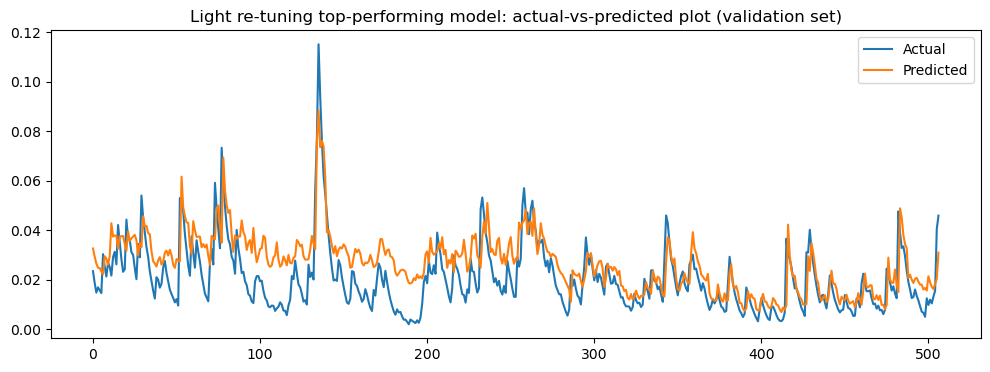

In [30]:
#Actual vs predicted plot (validation set)
plt.figure(figsize=(12,4))
plt.plot(y_true_wnev, label='Actual')
plt.plot(y_pred_wnev, label='Predicted')
plt.legend(); plt.title('Light re-tuning top-performing model: actual-vs-predicted plot (validation set)')

Not surprisingly, the held-out validation set displays slightly better outcomes (RMSE 0.0109, MAE 0.0088, R² 0.3248) in comparison to the cross-validation robustness check average metrics (RMSE 0.0154, MAE 0.0101, R² 0.3956). One more time, the largest difference appears in R², while RMSE and MAE remain close aligned, suggesting stable error magnitudes. Together with the actual-vs-predicted plot, these results highlights the model capacity to keep explanatory power on entirely unseen data. 

Overall, the findings point to the LSTM capacity in generalizing reasonably well, albeit some performance degradation is expected when transitioning to a truly out-of-sample validation set.

As both models generalizes well, it is time for the final assessment: understanding which of the two perform the best.

## FINAL COMPARISON

Let's re-load the models' evaluation metrics on the validation set and assess them side-by-side.


 RS + WN evaluation metrics (validation set):
-----------------------------------------------------
RMSE: 0.0124
MAE : 0.0104
R²  : 0.1360


 Light RS evaluation metrics (validation set):
-----------------------------------------------------
RMSE: 0.0109
MAE : 0.0088
R²  : 0.3248

Predicted vs Actual plot: regularized vs stacked model


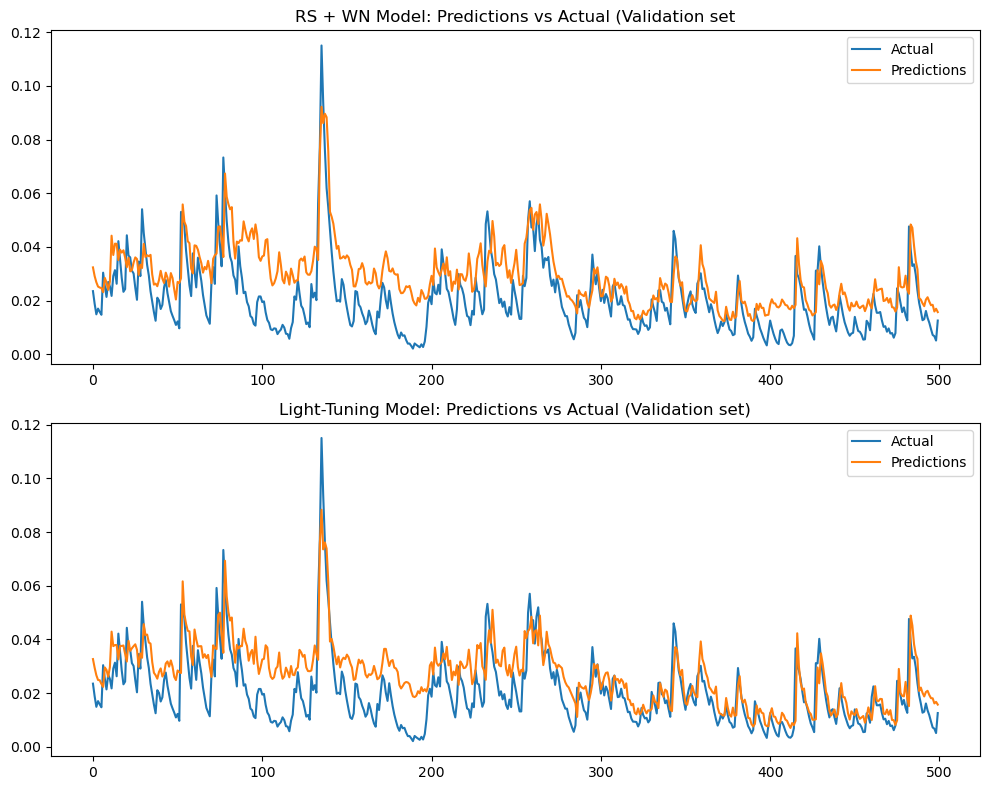

In [37]:
#RS + WN val metrics
print("\n RS + WN evaluation metrics (validation set):")
print("-----------------------------------------------------")
print(f"RMSE: {rmse_ranev:.4f}")
print(f"MAE : {mae_ranev:.4f}")
print(f"R²  : {r2_ranev:.4f}")
#space
print("")
#Light RS val metrics
print("\n Light RS evaluation metrics (validation set):")
print("-----------------------------------------------------")
print(f"RMSE: {rmse_wnev:.4f}")
print(f"MAE : {mae_wnev:.4f}")
print(f"R²  : {r2_wnev:.4f}")
print("")

#plots

# show the plots together
#RS+wn plot
#define fig and axis
fig1, ax1 = plt.subplots()
#build the fig as above
ax1.plot(y_true_ranev[:500], label='Actual')
ax1.plot(y_pred_ranev[:500], label='Predictions')
ax1.set_title("RS + WN Model: Predictions vs Actual (Validation set)")
ax1.legend()
#store the axis
ran_plot = ax1
#avoid showing it
plt.close(fig1)

#light-tuning plot
#define fig and axis
fig2, ax2 = plt.subplots()
#build the fig as above
ax2.plot(y_true_wnev[:500], label='Actual')
ax2.plot(y_pred_wnev[:500], label='Predictions')
ax2.set_title("Light-Tuning Model: Predictions vs Actual (Validation set)")
ax2.legend()
#store the axis
wn_plot = ax2
#avoid displaying it
plt.close(fig2)

#give a title
print("Predicted vs Actual plot: regularized vs stacked model")
#define the layout
fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(10, 8))
# Copy content from stored plots
#RS+WN
for line in ran_plot.lines:
    ax_top.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
ax_top.set_title("RS + WN Model: Predictions vs Actual (Validation set")
ax_top.legend()
#stacked
for line in wn_plot.lines:
    ax_bottom.plot(line.get_xdata(), line.get_ydata(), label=line.get_label())
ax_bottom.set_title("Light-Tuning Model: Predictions vs Actual (Validation set)")
ax_bottom.legend()
#show them
plt.tight_layout()
plt.show()

Between the two LSTMs, the light RS model demonstrates stronger generalization abilities on the hedl-out validation set. Its smaller RMSE (0.0109 vs. 0.0124) and MAE (0.0088 vs. 0.0104) highlights a lower prediction error; while its potential in explaining more variance in unseen data is reflected by the higher R² (0.325 vs. 0.136).

Although the differences are not substantial in absolute terms, they are systematic: the light RS' parameters set consistently outperforms the RS + WN model across all three metrics. This emphasizes how the former's hyperparameters setup better balances bias and variance, making it the more reliable and top-performing model.

As a result, the light RS model is stored as the LSTM champion model.

In [33]:
#save the top-performing model
wn_ran_ev_LSTM.save(final_save_path + "LSTM.keras")
#save the top-performing model's history
np.save(final_save_path + "LSTM_history.npy", wn_ran_ev_LSTM_history.history)
#show it was done
print("")
print("Champions LSTM model saved.")
print("")


Champions LSTM model saved.



### BONUS EVALUATION: DIRECTIONALITY ASSESSMENT

Financial data are ineherently volatile, driven by constantly and often unpredictably changing market dynamics.
As such, forecasting the magnitude of such fluctuations is challenging even for top-performing models. That's the reason why a certain degree of prediction error is typically acceptable.

However, a model's ability to correctly identify the direction of movements (ups and downs) must be as accurate as possible. While a small deviation in magnitude may lead to limited profit variation, misclassifying the direction can result in significantly larger financial losses.

To assess the champion model's directional accuracy, correlation between predicted vs actual values is computed. 

In [52]:
#Pearson correlation predicted-vs-actual
corr = np.corrcoef(x=y_pred_wnev, y=y_true_wnev)[0,1] 
#Note: [0,1] select the correlation coeff's spot in the correlation matrix
#print it
print("------------------------------------")
print("")
print("The directional correlation coefficient is:")
print(f"{corr:.4f}")
print("")

#direction accuracy (how many times the model get the right direction?)
direction_accuracy = np.mean(np.sign(y_pred_wnev) == np.sign(y_true_wnev))
#print it
print("")
print("The direction accuracy percentage is:")
print(f"{direction_accuracy*100}")
print("")

print("------------------------------------")

------------------------------------

The directional correlation coefficient is:
0.7444


The direction accuracy percentage is:
100.0

------------------------------------


The correlation between the predicted and actual values is a strong positive correlation (0.7444); reinforcing the model's ability to catch both direction and relative magnitude of volatility movements. Although not perfectly aligned, a correlation above 0.7 in such a noisy financial context signals that the model consistently tracks the underlying trend and reacts coherently to fluctuations. 
That's it: even if minor deviations happens in the exact magnitude of change, the model effectively learned the structure and direction of volatility dynamics. The 100% direction accuracy (i.e the ability to rightly predict fluctuations' directions) strongly supports this conclusion.

Taken together, these results highlight the champions LSTM's robustness.